Testing pyrtlib

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.abspath('..'))  # on est dans notebooks/

In [41]:
# Ajoute la racine du projet et importe les modules/fonctions utiles
import sys, os
from pathlib import Path


# import pratique - atm_tools
from src.cosmo_lidar.atm_tools import (
    effective_area_and_waist,
    alpha_specific_function,
    optical_depth_emission,
    contribution_effective_area,
    Calcul_T_ant_1_el,
    Calcul_T_ant_2,
    Calcul_T_sky_1_el,
    calcul_PWV,
    calcul_z_percentile_wvc,
    vapor_pressure,
    mass_quantile_grid,
    pwv_profile,
)

# import pratique - mc_tools
from src.cosmo_lidar.mc_tools import (
    generate_Pwater_MC,
    generate_Pwater_MC_lognormal,
    monte_carlo_t_ant,
    calcul_snr,
    remove_nans,
    Monte_Carlo_T_ant_mod,
    local_bin_width,
    scale_snr_for_variable_bins,
    predict_SNR_T,
    hybrid_lin_geom,
    Monte_Carlo_T_ant_profile,
)

# import pratique - io
from src.cosmo_lidar.io import (
    fetch_html,
    extract_ut_column_dat_links,
    download_some,
    read_radiosonde_dat,
    read_many_radiosonde,
    save_table,
    load_table,
    load_parquet_columns_as_numpy,
    to_float64,
)

import numpy as np
pi = np.pi
from scipy.interpolate import UnivariateSpline
from scipy.integrate import simpson
from scipy.integrate import trapezoid, cumulative_trapezoid
from matplotlib import pyplot as plt
import pandas as pd
import pycraf
from pycraf import conversions as cnv
from astropy import units as u

<Axes: xlabel='Frequency [GHz]', ylabel='Brightness Temperature [K]'>

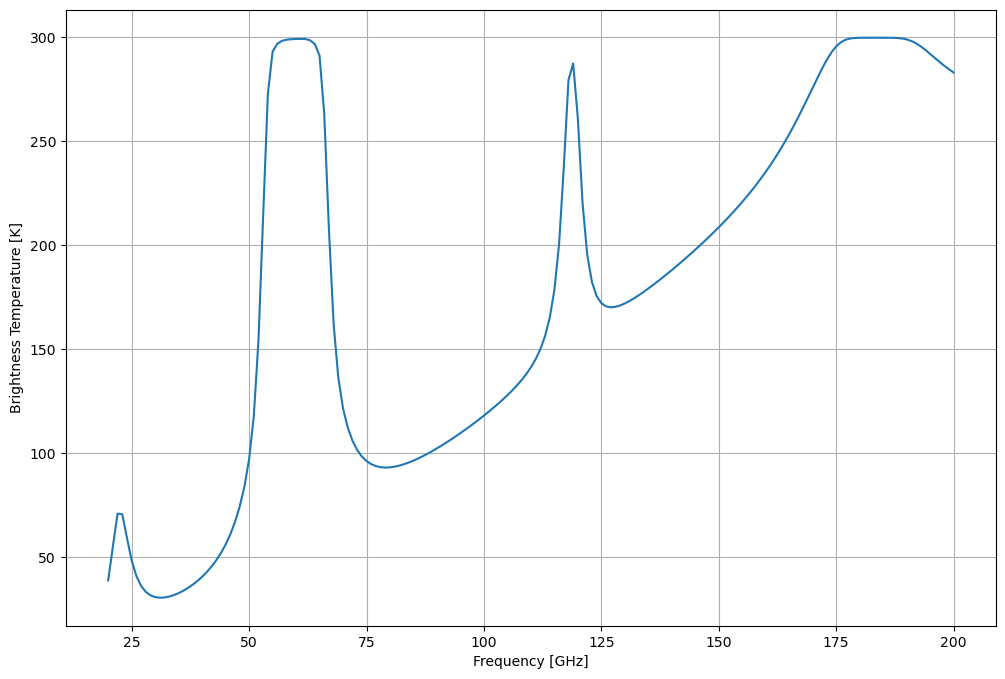

In [8]:
import numpy as np
from pyrtlib.tb_spectrum import TbCloudRTE
from pyrtlib.climatology import AtmosphericProfiles as atmp
from pyrtlib.utils import ppmv2gkg, mr2rh, _dcerror, constants
from pyrtlib.absorption_model import H2OAbsModel

# ==============================================================================
# REMPLACEMENT INTÉGRAL DE LA MÉTHODE H2O POUR CORRIGER LE BUG INTERNE (df[j])
# ==============================================================================
def fixed_h2o_absorption(self, pdrykpa, vx, ekpa, frq, amu=None):
    if amu:
        if H2OAbsModel.model > 'R17':
            self.h2oll.cf = amu['con_Cf'].value
            self.h2oll.cs = amu['con_Cs'].value
        else:
            self.h2oll.cf = amu['con_Cf'].value * amu['con_Cf_factr'].value
            self.h2oll.cs = amu['con_Cs'].value * amu['con_Cs_factr'].value
        self.h2oll.xcf = amu['con_Xf'].value
        self.h2oll.xcs = amu['con_Xs'].value
        self.h2oll.s1 = amu['S'].value
        self.h2oll.b2 = amu['B2'].value
        self.h2oll.w0 = amu['gamma_a'].value / 1000.0
        self.h2oll.w0s = amu['gamma_w'].value / 1000.0
        self.h2oll.x = amu['n_a'].value
        self.h2oll.xs = amu['n_w'].value
        if H2OAbsModel.model > 'R17':
            self.h2oll.sh = amu['delta_a'].value / 1000.0
            self.h2oll.shs = amu['delta_w'].value / 1000.0
            self.h2oll.xh = amu['n_da'].value
            self.h2oll.xhs = amu['n_dw'].value
        else:
            self.h2oll.sr = amu['SR'].value
        self.h2oll.fl = amu['FL'].value

    db2np = np.log(10.0) * 0.1
    rvap = (0.01 * 8.31451) / 18.01528
    factor = 0.182 * frq
    t = 300.0 / vx
    p = (pdrykpa + ekpa) * 10.0
    rho = ekpa * 10.0 / (rvap * t)
    f = frq

    if rho.any() <= 0.0:
        return 0, 0

    pvap = (rho * t) / 216.68
    if H2OAbsModel.model in ['R03', 'R16', 'R17', 'R98']:
        pvap = (rho * t) / 217.0
    if H2OAbsModel.model in ['R22SD', 'R23SD', 'R24', 'MWL24']:
        pvap = (constants("Rwatvap")[0] * 1e-05) * rho * t
    pda = p - pvap
    if H2OAbsModel.model in ['R03', 'R16', 'R98']:
        den = 3.335e+16 * rho
    else:
        den = 3.344e+16 * rho

    ti = self.h2oll.reftcon / t
    if H2OAbsModel.model in ['R03', 'R98']:
        con = (5.43e-10 * pda * ti ** 3 + 1.8e-08 * pvap * ti ** 7.5) * pvap * f * f
    elif H2OAbsModel.model == 'MWL24':
        con_self = self.h2o_continuum_mwl24(f, vx) * pvap * pvap
        con_frgn = 7.1e-10 * (300./t)**4.4 * f**1.96 * pda * pvap
        con = con_self + con_frgn
    else:
        con = (self.h2oll.cf * pda * ti ** self.h2oll.xcf + self.h2oll.cs * pvap * ti ** self.h2oll.xcs) * pvap * f * f

    nlines = len(self.h2oll.fl)
    ti = self.h2oll.reftline / t
    
    # === LE CORRECTIF CRUCIAL EST ICI ===
    df = np.zeros(2) # Remplacement de np.zeros((2,1)) pour éviter les array 2D
    # ====================================

    if H2OAbsModel.model.startswith(('R19SD', 'R20SD', 'R21SD', 'R22SD', 'R23SD', 'R24', 'MWL24')):
        tiln = np.log(ti)
        ti2 = np.exp(2.5 * tiln)
        summ = 0.0
        if H2OAbsModel.model in ['R23SD', 'R24']:
            if self.h2oll.cs > 0:
                con = self.h2oll.cs * ti * self.h2oll.xcs
                npp_cs = con
            else:
                npp_cs = self.h2o_continuum(frq, vx, 1)
        for i in range(0, nlines):
            width0 = self.h2oll.w0[i] * pda * ti ** self.h2oll.x[i] + self.h2oll.w0s[i] * pvap * ti ** self.h2oll.xs[i]
            width2 = self.h2oll.w2[i] * pda + self.h2oll.w2s[i] * pvap
            if H2OAbsModel.model in ['R21SD', 'R22SD', 'R23SD', 'R24', 'MWL24']:
                if self.h2oll.w2[i] > 0:
                    width2 = self.h2oll.w2[i] * pda * ti ** self.h2oll.xw2[i] + self.h2oll.w2s[i] * pvap * ti ** self.h2oll.xw2s[i]
                else:
                    width2 = 0
            shiftf = self.h2oll.sh[i] * pda * (1. - self.h2oll.aair[i] * tiln) * ti ** self.h2oll.xh[i]
            shifts = self.h2oll.shs[i] * pvap * (1. - self.h2oll.aself[i] * tiln) * ti ** self.h2oll.xhs[i]
            shift = shiftf + shifts
            wsq = width0 ** 2
            s = self.h2oll.s1[i] * ti2 * np.exp(self.h2oll.b2[i] * (1. - ti))
            df[0] = f - self.h2oll.fl[i] - shift
            df[1] = f + self.h2oll.fl[i] + shift
            base = width0 / (562500.0 + wsq)
            if H2OAbsModel.model in ["R21SD", 'R22SD', 'R23SD', 'R24', 'MWL24']:
                delta2 = self.h2oll.d2[i] * pda + self.h2oll.d2s[i] * pvap
            res = 0.0
            for j in range(0, 2):
                if width2 > 0 and j == 0 and np.abs(df[j]) < (10 * width0):
                    xc = complex((width0 - np.dot(1.5, width2)), df[j]) / width2
                    if H2OAbsModel.model == 'R20SD':
                        if i == 1:
                            delta2 = (self.h2oll.d2air * pda) + (self.h2oll.d2self * pvap)
                        else:
                            delta2 = 0.0
                        xc = complex((width0 - np.dot(1.5, width2)), df[j] + np.dot(1.5, delta2)) / complex(width2, -delta2)
                    elif H2OAbsModel.model in ["R21SD", 'R22SD', 'R23SD', 'R24', 'MWL24']:
                        xc = complex((width0 - 1.5 * width2), df[j] + 1.5 * delta2) / complex(width2, -delta2)
                    xrt = np.sqrt(xc)
                    pxw = 1.77245385090551603 * xrt * _dcerror(-np.imag(xrt), np.real(xrt))
                    sd = 2.0 * (1.0 - pxw) / (width2 if H2OAbsModel.model not in ['R20SD', 'R21SD', 'R22SD', 'R23SD', 'R24', 'MWL24'] else complex(width2, -delta2))
                    res += np.real(sd) - base
                elif np.abs(df[j]) < 750.0:
                    res += width0 / (df[j] ** 2 + wsq) - base
            summ += s * res * (f / self.h2oll.fl[i]) ** 2
    elif H2OAbsModel.model in ['R16', 'R03', 'R17', 'R98']:
        ti2 = ti ** 2.5
        summ = 0.0
        for i in range(0, nlines):
            widthf = self.h2oll.w0[i] * pda * ti ** self.h2oll.x[i]
            widths = self.h2oll.w0s[i] * pvap * ti ** self.h2oll.xs[i]
            width = widthf + widths
            shift = 0.0 if H2OAbsModel.model == 'R98' else self.h2oll.sr[i] * (width if H2OAbsModel.model == 'R03' else widthf)
            wsq = width ** 2
            s = self.h2oll.s1[i] * ti2 * np.exp(self.h2oll.b2[i] * (1.0 - ti))
            df[0] = f - self.h2oll.fl[i] - shift
            df[1] = f + self.h2oll.fl[i] + shift
            base = width / (562500.0 + wsq)
            res = 0.0
            for j in range(0, 2):
                if np.abs(df[j]) <= 750.0:
                    res += width / (df[j] ** 2 + wsq) - base
            summ += s * res * (f / self.h2oll.fl[i]) ** 2
    elif H2OAbsModel.model in ['R19', 'R20']:
        tiln = np.log(ti)
        ti2 = ti ** 2.5
        summ = 0.0
        for i in range(0, nlines):
            widthf = self.h2oll.w0[i] * pda * ti ** self.h2oll.x[i]
            widths = self.h2oll.w0s[i] * pvap * ti ** self.h2oll.xs[i]
            width = widthf + widths
            shiftf = self.h2oll.sh[i] * pda * (1. - self.h2oll.aair[i] * tiln) * ti ** self.h2oll.xh[i]
            shifts = self.h2oll.shs[i] * pvap * (1. - self.h2oll.aself[i] * tiln) * ti ** self.h2oll.xhs[i]
            shift = shiftf + shifts
            wsq = width ** 2
            s = self.h2oll.s1[i] * ti2 * np.exp(self.h2oll.b2[i] * (1. - ti))
            df[0] = f - self.h2oll.fl[i] - shift
            df[1] = f + self.h2oll.fl[i] + shift
            base = width / (562500.0 + wsq)
            res = 0.0
            for j in range(0, 2):
                if np.abs(df[j]) < 750.0:
                    res += width / (df[j] ** 2 + wsq) - base
            summ += s * res * (f / self.h2oll.fl[i]) ** 2
    elif H2OAbsModel.model == 'R18':
        ti2 = ti ** 2.5
        summ = 0.0
        for i in range(0, nlines):
            widthf = self.h2oll.w0[i] * pda * ti ** self.h2oll.x[i]
            widths = self.h2oll.w0s[i] * pvap * ti ** self.h2oll.xs[i]
            width = widthf + widths
            shiftf = self.h2oll.sh[i] * pda * ti ** self.h2oll.xh[i]
            shifts = self.h2oll.shs[i] * pvap * ti ** self.h2oll.xhs[i]
            shift = shiftf + shifts
            wsq = width ** 2
            s = self.h2oll.s1[i] * ti2 * np.exp(self.h2oll.b2[i] * (1. - ti))
            df[0] = f - self.h2oll.fl[i] - shift
            df[1] = f + self.h2oll.fl[i] + shift
            base = width / (562500.0 + wsq)
            res = 0.0
            for j in range(0, 2):
                if np.abs(df[j]) < 750.0:
                    res += width / (df[j] ** 2 + wsq) - base
            summ += s * res * (f / self.h2oll.fl[i]) ** 2

    if H2OAbsModel.model in ['R23SD', 'R24']:
        conf = self.h2oll.cf * ti**self.h2oll.xcf
        con = (conf * pda + npp_cs * pvap) * pvap * f**2

    h20m = 2.9915075E-23
    if H2OAbsModel.model in ['R22SD', 'R23SD']:
        npp = 1.e-10 * rho * summ / (np.pi * h20m) / db2np / factor
    elif H2OAbsModel.model == 'R24':
        npp = 1.e-10 * (rho/h20m) * (summ/np.pi) / db2np / factor
    else:
        npp = (3.1831e-05 * den * summ / db2np) / factor

    ncpp = (con / db2np) / factor
    return float(np.squeeze(npp)), float(np.squeeze(ncpp))

# On écrase la méthode originale par notre version saine
H2OAbsModel.h2o_absorption = fixed_h2o_absorption
# ==============================================================================

# --- VOTRE CODE PRINCIPAL ---
z, p, _, t, md = atmp.gl_atm(atmp.TROPICAL)


gkg = ppmv2gkg(np.squeeze(md[:, atmp.H2O]), atmp.H2O)

rh = mr2rh(p, t, gkg)[0] / 100

ang = [90.]
frq = np.arange(20, 201, 1)

rte = TbCloudRTE(z, p, t, rh, frq, ang)
rte.init_absmdl('R19SD')
rte.satellite = False

df = rte.execute()
df = df.set_index(frq)
df.tbtotal.plot(figsize=(12,8), xlabel="Frequency [GHz]", ylabel="Brightness Temperature [K]", grid=True)

In [19]:
from pyrtlib.tb_spectrum import TbCloudRTE
from pyrtlib.climatology import AtmosphericProfiles as atmp
from pyrtlib.utils import ppmv2gkg, mr2rh

z, p, _, t, md = atmp.gl_atm(atmp.TROPICAL)
gkg = ppmv2gkg(md[:, atmp.H2O], atmp.H2O)
rh = mr2rh(p, t, gkg)[0] / 100

ang = np.array([90.])
frq = np.arange(20, 201, 1)

rte = TbCloudRTE(z, p, t, rh, frq, ang)
rte.init_absmdl('R19SD')
rte.satellite = False
df = rte.execute()
df = df.set_index(frq)
df.tbtotal.plot(figsize=(12,8), xlabel="Frequency [GHz]", ylabel="Brightness Temperature [K]", grid=True)

RecursionError: maximum recursion depth exceeded

<Axes: xlabel='Frequency [GHz]', ylabel='Brightness Temperature [K]'>

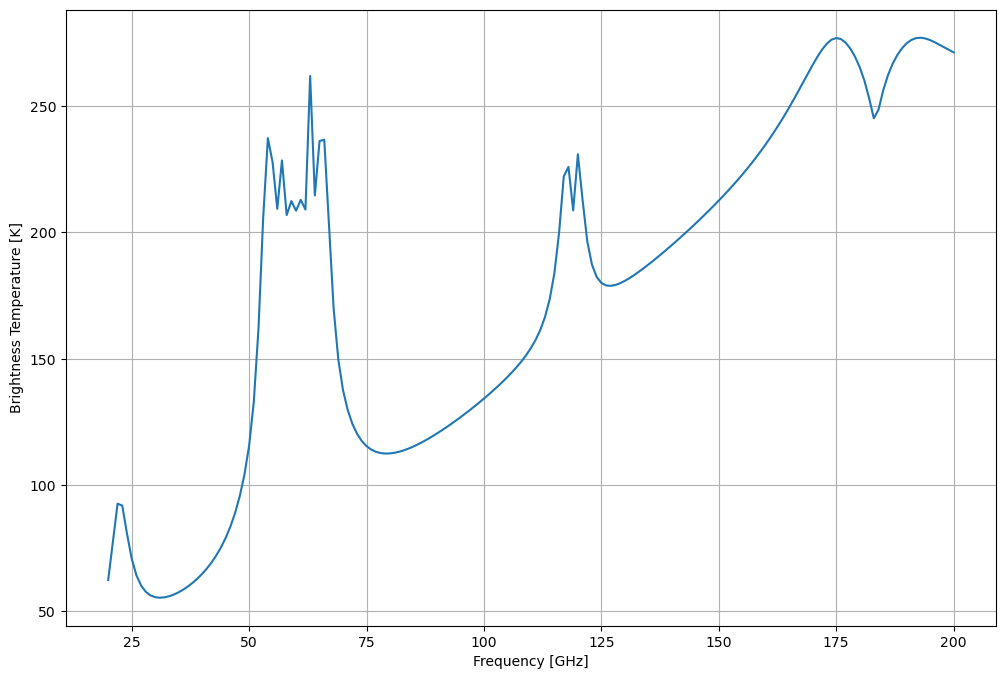

In [ ]:
from pyrtlib.tb_spectrum import TbCloudRTE
from pyrtlib.absorption_model import H2OAbsModel, O2AbsModel, O3AbsModel
from pyrtlib.climatology import AtmosphericProfiles as atmp
from pyrtlib.utils import ppmv2gkg, mr2rh

z, p, _, t, md = atmp.gl_atm(atmp.TROPICAL)
gkg = ppmv2gkg(md[:, atmp.H2O], atmp.H2O)
rh = mr2rh(p, t, gkg)[0] / 100

ang = np.array([90.])
frq = np.arange(20, 201, 1)

rte = TbCloudRTE(z, p, t, rh, frq, ang)
rte.emissivity = 0.1
rte.init_absmdl('R19SD')
H2OAbsModel.model = 'R22SD'
H2OAbsModel.set_ll()
O2AbsModel.model = 'R16'
O2AbsModel.set_ll()
df = rte.execute()
df = df.set_index(frq)
df.tbtotal.plot(figsize=(12,8), xlabel="Frequency [GHz]", ylabel="Brightness Temperature [K]", grid=True)

In [102]:
from pyrtlib.absorption_model import AbsModel

AbsModel.implemented_models()

{'Oxygen': ['R98',
  'R03',
  'R16',
  'R17',
  'R18',
  'R19',
  'R19SD',
  'R20',
  'R20SD',
  'R22',
  'R23',
  'R24'],
 'WaterVapour': ['R98',
  'R03',
  'R16',
  'R17',
  'R18',
  'R19',
  'R19SD',
  'R20',
  'R20SD',
  'R21SD',
  'R22SD',
  'R23SD',
  'R24',
  'MWL24'],
 'Ozone': ['R18', 'R22', 'R23']}

Comparison pycraf pyrtlib

In [198]:
import numpy as np
from pyrtlib.tb_spectrum import TbCloudRTE
from pyrtlib.climatology import AtmosphericProfiles as atmp
from pyrtlib.utils import ppmv2gkg, mr2rh, _dcerror, constants, mr2e, ppmv_to_moleculesm3

In [212]:

z, p, _, t, md = atmp.gl_atm(atmp.TROPICAL) #gives atm profile z in km, p in hPa, T in K, md molecular densities in ppmv


gkg = ppmv2gkg(np.squeeze(md[:, atmp.H2O]), atmp.H2O) #wvmr in g/kg

rh = mr2rh(p, t, gkg)[0] / 100  # RH (not % anymore)

pw= mr2e (p, gkg)  #partial water vapor in hPa


o3n_ppmv = md[:, atmp.O3]
o3n = np.zeros(z.shape)
for k in range(0, len(z)):
    o3n[k] = ppmv_to_moleculesm3(o3n_ppmv[k], p[k] * 100.0, t[k])

ang = [90.]
frq = np.arange(75, 302, 1)

rte = TbCloudRTE(z, p, t, rh, frq, ang, o3n)
rte.init_absmdl('R19SD')
rte.satellite = False

df, variables = rte.execute(False)
df = df.set_index(frq)

tbatm = df.tbatm.values
PWV = variables['srho']

In [164]:
print(z)

[  0.    1.    2.    3.    4.    5.    6.    7.    8.    9.   10.   11.
  12.   13.   14.   15.   16.   17.   18.   19.   20.   21.   22.   23.
  24.   25.   27.5  30.   32.5  35.   37.5  40.   42.5  45.   47.5  50.
  55.   60.   65.   70.   75.   80.   85.   90.   95.  100.  105.  110.
 115.  120. ]


In [166]:
print(PWV)

[[4.04868615]]


In [40]:
print(tbatm)

[ 95.15697913  93.66327985  92.72102056  92.2103838   92.0433917
  92.15415896  92.49250179  93.01962523  93.70514907  94.52501186
  95.45996921  96.4945013   97.61600794  98.81420932 100.0806965
 101.40859292 102.7923001  104.22730886 105.71006362 107.23786609
 108.80882628 110.42184535 112.07663922 113.77380581 115.51494826
 117.30286742 119.14185223 121.03810828 123.00039024 125.04094288
 127.17692344 129.43259561 131.84279898 134.45859734 137.35678681
 140.65652358 144.54967901 149.35896994 155.65503524 164.50331129
 177.99181045 200.20399268 237.02465698 279.31595181 287.28846188
 260.65634697 219.86118519 194.87818553 181.83128488 175.09915239
 171.69660234 170.14744013 169.69313329 169.92141372 170.59574426
 171.57380101 172.76631821 174.11536381 175.58225508 177.14055027
 178.77185164 180.46320513 182.20544497 183.99211409 185.81874593
 187.68237875 189.58122453 191.51443978 193.48197008 195.48444464
 197.52310803 199.59977965 201.71683451 203.87720106 206.08437272
 208.3395857

<Axes: xlabel='Frequency [GHz]', ylabel='Brightness Temperature [K]'>

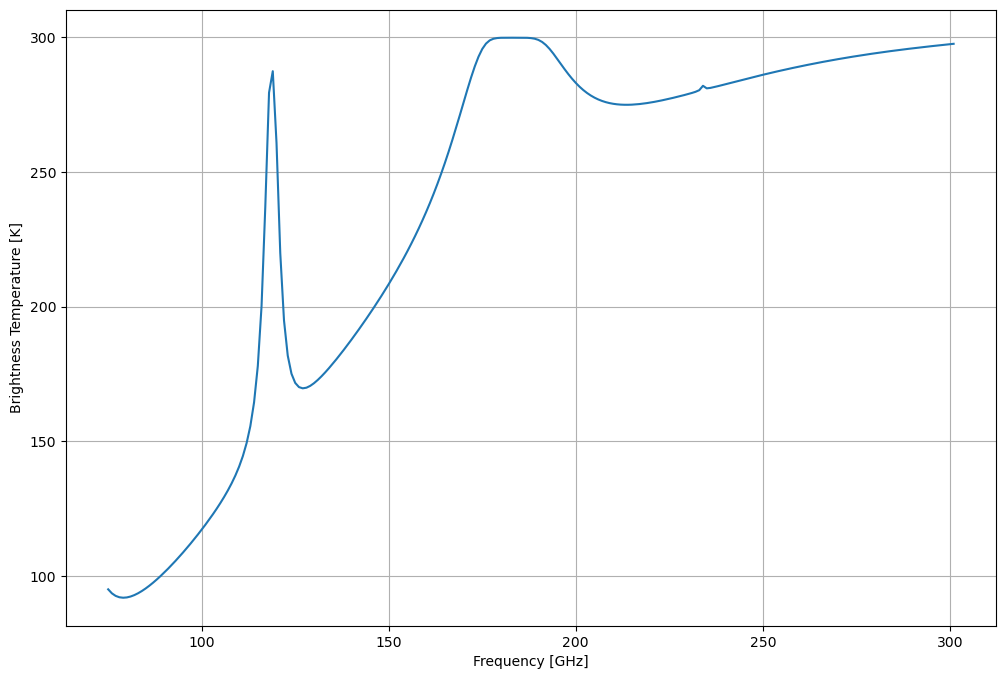

In [202]:
df.tbatm.plot(figsize=(12,8), xlabel="Frequency [GHz]", ylabel="Brightness Temperature [K]", grid=True)

In [149]:
print(z)

[  0.    1.    2.    3.    4.    5.    6.    7.    8.    9.   10.   11.
  12.   13.   14.   15.   16.   17.   18.   19.   20.   21.   22.   23.
  24.   25.   27.5  30.   32.5  35.   37.5  40.   42.5  45.   47.5  50.
  55.   60.   65.   70.   75.   80.   85.   90.   95.  100.  105.  110.
 115.  120. ]


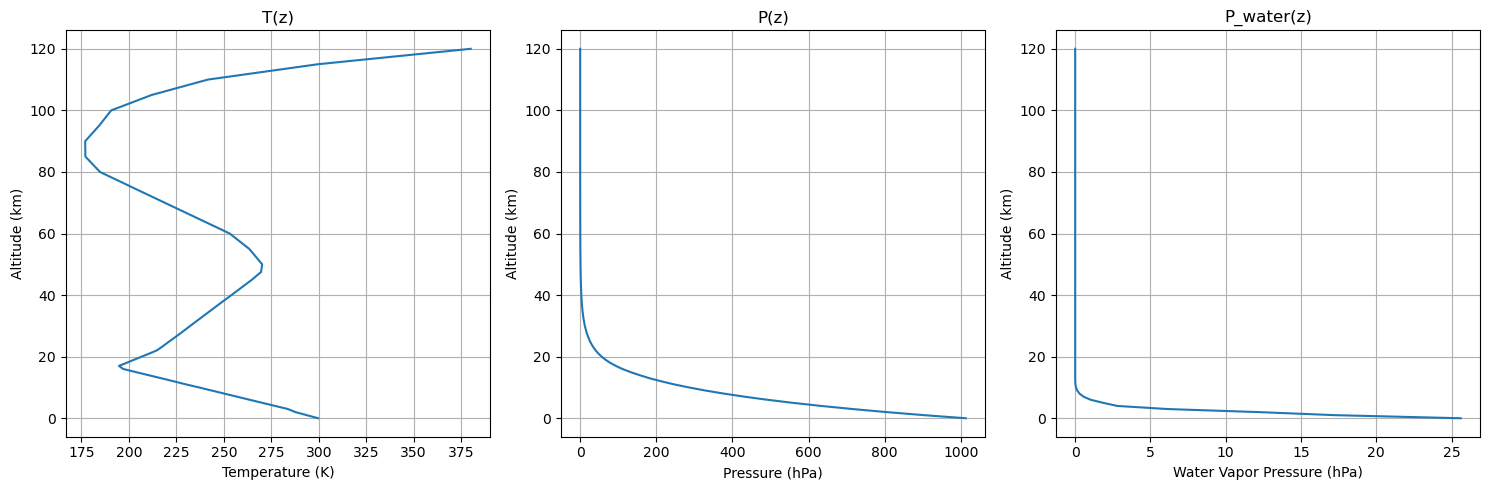

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Temperature vs Altitude
axs[0].plot(t, z)
axs[0].set_xlabel('Temperature (K)')
axs[0].set_ylabel('Altitude (km)')
axs[0].set_title('T(z)')
axs[0].grid(True)

# Pressure vs Altitude
axs[1].plot(p, z)
axs[1].set_xlabel('Pressure (hPa)')
axs[1].set_ylabel('Altitude (km)')
axs[1].set_title('P(z)')
axs[1].grid(True)

# Water Vapor Pressure vs Altitude
axs[2].plot(pw, z)
axs[2].set_xlabel('Water Vapor Pressure (hPa)')
axs[2].set_ylabel('Altitude (km)')
axs[2].set_title('P_water(z)')
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#pycraf calculation of the brightness temperature spectrum

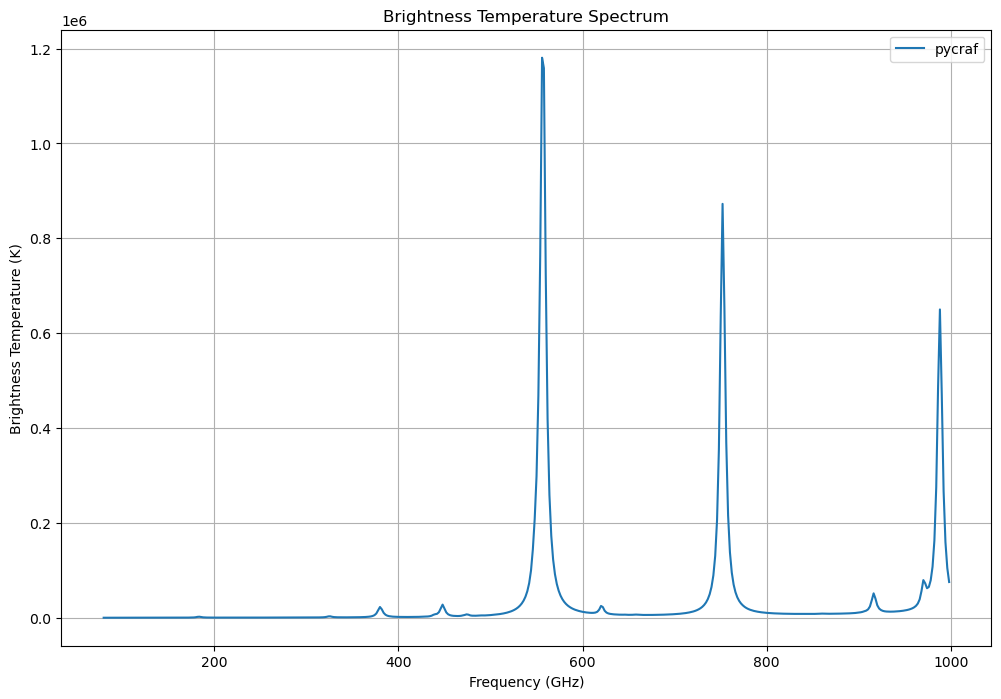

In [267]:
Tatm_pycraf = Calcul_T_sky_1_el(frq*1e9, z*1000, t, p, pw, 90)

plt.figure(figsize=(12,8))
plt.plot(frq, Tatm_pycraf, label='pycraf')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum')
plt.legend()
plt.grid()
plt.show()

In [213]:
alpha_issue = alpha_specific_function(z*1000, frq*10**9, t, p, pw)

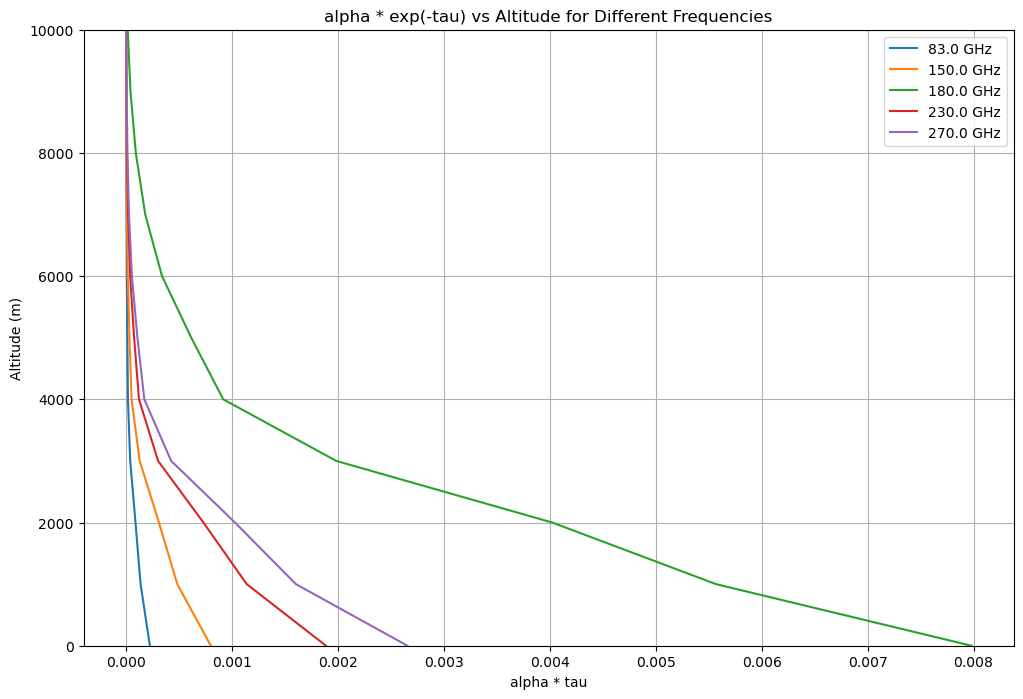

In [214]:
#we plot for different frequencies, alpha_issue*tau_issue vs altitude
plt.figure(figsize=(12,8))
for f in [83e9, 150e9, 180e9, 230e9, 270e9]:
    plt.plot(alpha_issue[:, np.where(frq*10**9 == f)[0][0]], z*1000, label=f'{f/1e9} GHz')
plt.xlabel('alpha * tau')
plt.ylabel('Altitude (m)')
plt.title('alpha * exp(-tau) vs Altitude for Different Frequencies')
plt.legend()
plt.ylim(0,10000)
plt.grid()
plt.show()

In [215]:
tau_issue = optical_depth_emission(z*1000, alpha_issue)

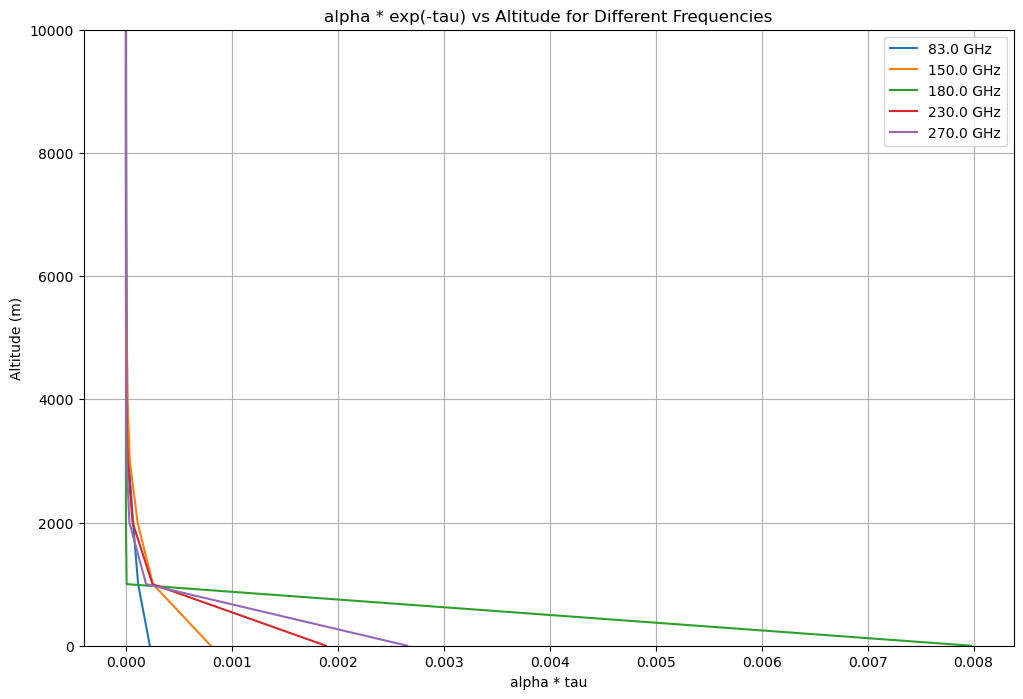

In [216]:
#we plot for different frequencies, alpha_issue*tau_issue vs altitude
plt.figure(figsize=(12,8))
for f in [83e9, 150e9, 180e9, 230e9, 270e9]:
    plt.plot(alpha_issue[:, np.where(frq*10**9 == f)[0][0]] * np.exp(-tau_issue[:, np.where(frq*10**9 == f)[0][0]]), z*1000, label=f'{f/1e9} GHz')
plt.xlabel('alpha * tau')
plt.ylabel('Altitude (m)')
plt.title('alpha * exp(-tau) vs Altitude for Different Frequencies')
plt.legend()
plt.ylim(0,10000)
plt.grid()
plt.show()

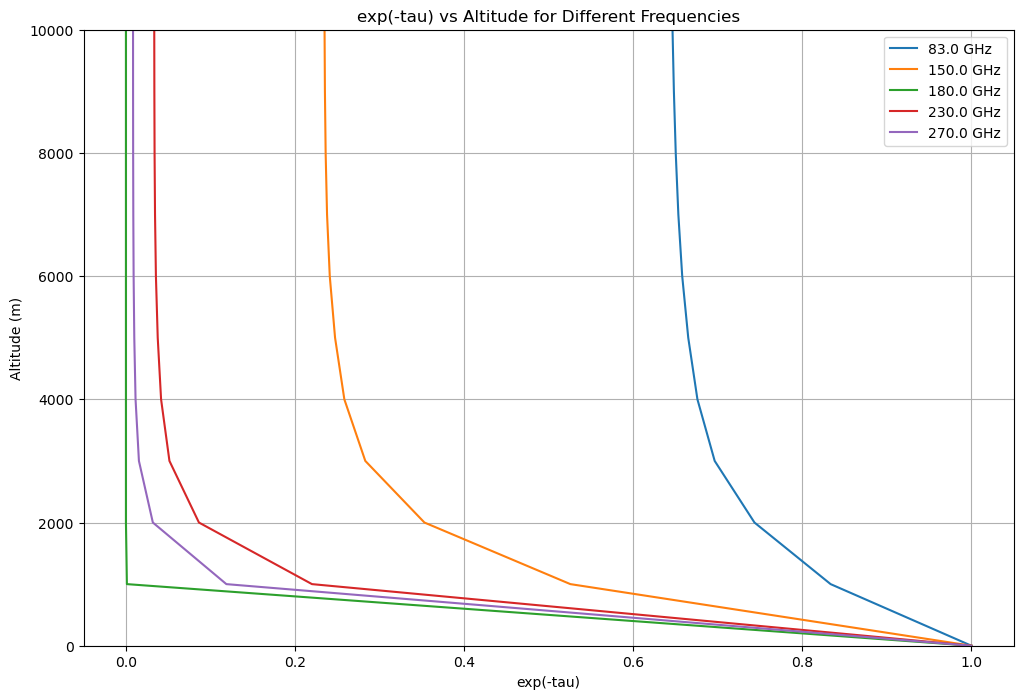

In [218]:
#we plot for different frequencies, alpha_issue*tau_issue vs altitude
plt.figure(figsize=(12,8))
for f in [83e9, 150e9, 180e9, 230e9, 270e9]:
    plt.plot( np.exp(-tau_issue[:, np.where(frq*10**9 == f)[0][0]]), z*1000, label=f'{f/1e9} GHz')
plt.xlabel('exp(-tau)')
plt.ylabel('Altitude (m)')
plt.title('exp(-tau) vs Altitude for Different Frequencies')
plt.legend()
plt.ylim(0,10000)
plt.grid()
plt.show()

In [177]:
import numpy as np

def estimate_trapezoidal_error(altitudes, C_tot):
    """
    Estimates the truncation error of the trapezoidal rule for your atmospheric data.
    
    Parameters:
    - altitudes: 1D array of altitudes in meters (length N)
    - C_tot: The function you are integrating (shape N, or N x M for frequencies)
    
    Returns:
    - total_error: The total estimated error added to T_sky (in Kelvin)
    - local_errors: The error generated at each specific altitude step
    """
    # 1. Calculate the step sizes (Delta z_i) for each interval
    # This creates an array of length N-1
    dz = np.diff(altitudes)
    
    # If C_tot is 2D (altitudes x frequencies), reshape dz for broadcasting
    if C_tot.ndim == 2:
        dz = dz[:, np.newaxis]

    # 2. Estimate the first and second derivatives numerically
    # axis=0 ensures we differentiate along the altitude dimension, not frequency
    f_prime = np.gradient(C_tot, altitudes, axis=0)
    f_double_prime = np.gradient(f_prime, altitudes, axis=0)

    # 3. Approximate f''(xi) for the interval [z_i, z_{i+1}]
    # We average the second derivative at the two endpoints of the interval
    f_double_prime_mid = (f_double_prime[:-1] + f_double_prime[1:]) / 2.0

    # 4. Apply the mathematical error formula: E_i = - ((dz)^3 / 12) * f''(xi)
    local_errors = - (dz**3 / 12.0) * f_double_prime_mid

    # 5. Sum the local errors to get the total estimated error for T_sky
    total_error = np.sum(local_errors, axis=0)

    return total_error, local_errors

In [178]:
C_tot = t[:,None] * alpha_issue * np.exp(-tau_issue)

total_error, local_errors = estimate_trapezoidal_error(z*1000, C_tot)

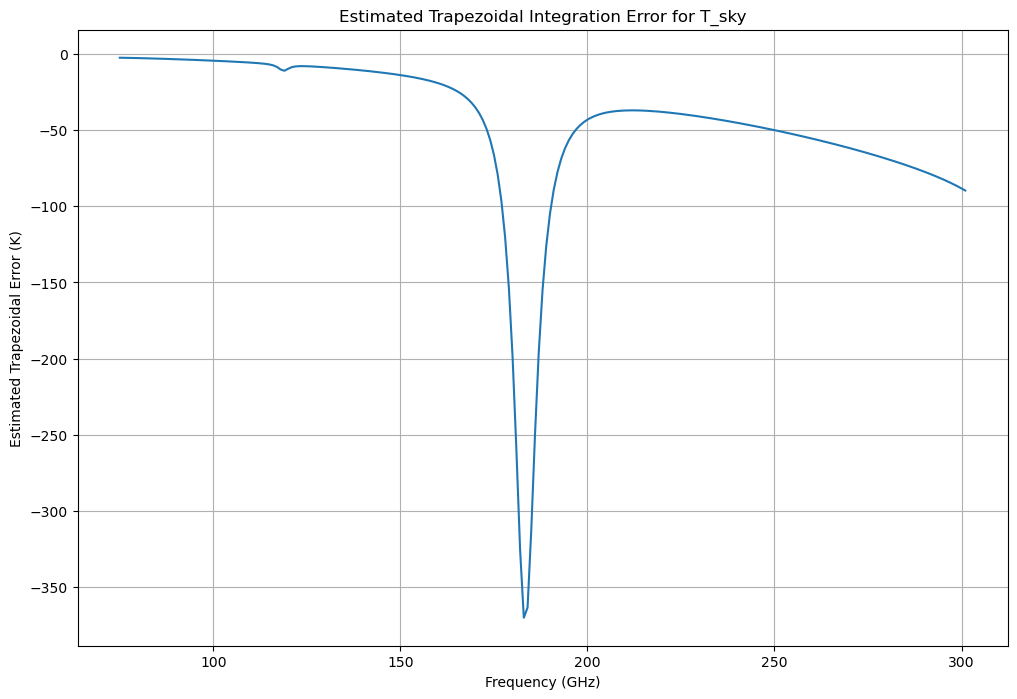

In [180]:
plt.figure(figsize=(12,8))
plt.plot(frq, total_error)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Estimated Trapezoidal Error (K)')
plt.title('Estimated Trapezoidal Integration Error for T_sky')
plt.grid()
plt.show()

comparaison between pycraf and pyrtlib

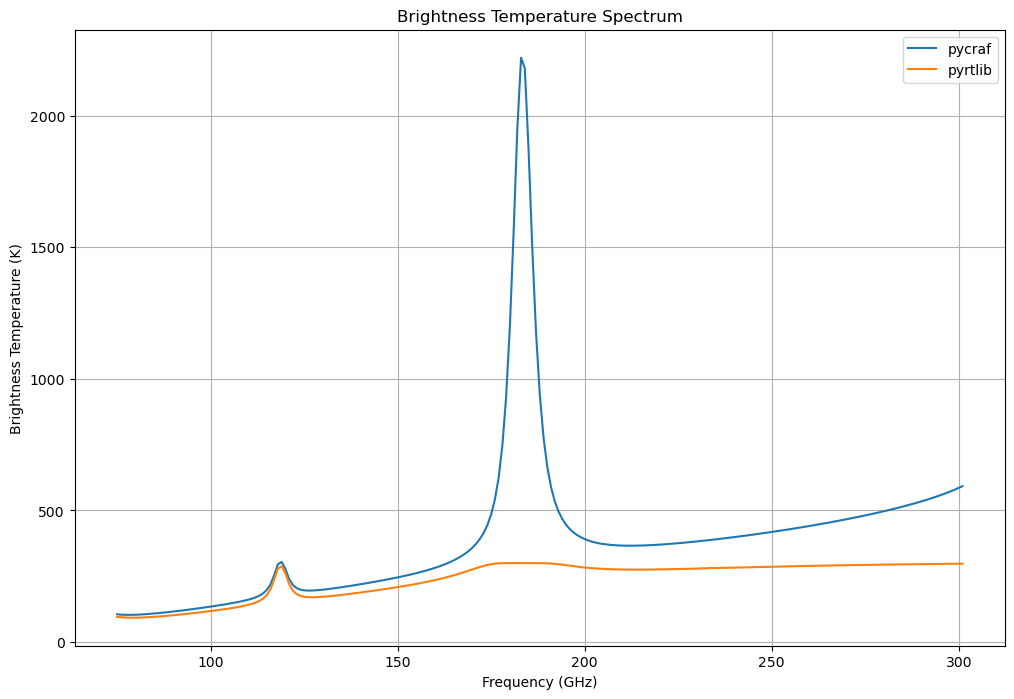

In [60]:
plt.figure(figsize=(12,8))
plt.plot(frq, Tatm_pycraf, label='pycraf')
plt.plot(frq, tbatm, label='pyrtlib')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum')
plt.legend()
plt.grid()
plt.show()

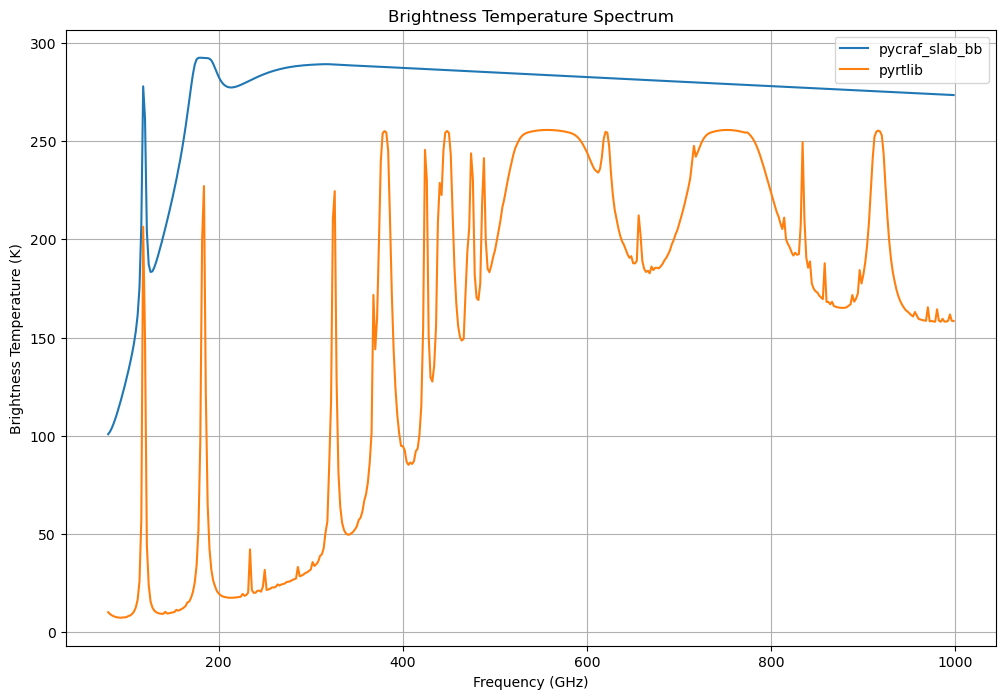

In [262]:
from src.cosmo_lidar.atm_tools import Calcul_T_sky_Slab_bb

Tatm_pycraf_slab_bb = Calcul_T_sky_Slab_bb(frq*1e9, z*1000, t, p, pw, 90)

plt.figure(figsize=(12,8))
plt.plot(frq, Tatm_pycraf_slab_bb, label='pycraf_slab_bb')
plt.plot(frq, tbatm, label='pyrtlib')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum')
plt.legend()
plt.grid()
plt.show()

Comparison with a more precise grid

In [236]:
#pycraf grid
frq = np.arange(80,1000,2) #GHz

altitudes = np.geomspace(1, 25000, 1000) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa

In [237]:
z_std, p_std, _, t_std, md_std = atmp.gl_atm(atmp.TROPICAL) #gives atm profile z in km, p in hPa, T in K, md molecular densities in ppmv

z_std = np.squeeze(z_std)
o3n_ppmv_std = np.squeeze(md_std[:, atmp.O3])

# ==========================================
# 3. Interpolate and Convert to molecules/m^3
# ==========================================
# First, interpolate the ppmv profile to your 1000-point grid
z_target = altitudes_km.value

o3n_ppmv_interp = np.interp(z_target, z_std, o3n_ppmv_std)

# Now, apply your conversion loop using the local pycraf Pressure and Temperature
o3n = np.zeros(z_target.shape)

for k in range(0, len(z_target)):
    # Pressure is in hPa, so multiplying by 100.0 converts it to Pascals (Pa)
    o3n[k] = ppmv_to_moleculesm3(o3n_ppmv_interp[k], Pressure[k] * 100.0, Temperature[k])

print(f"Altitude array size: {len(z_target)}")
print(f"Ozone array (o3n) size: {len(o3n)}")

Altitude array size: 1000
Ozone array (o3n) size: 1000


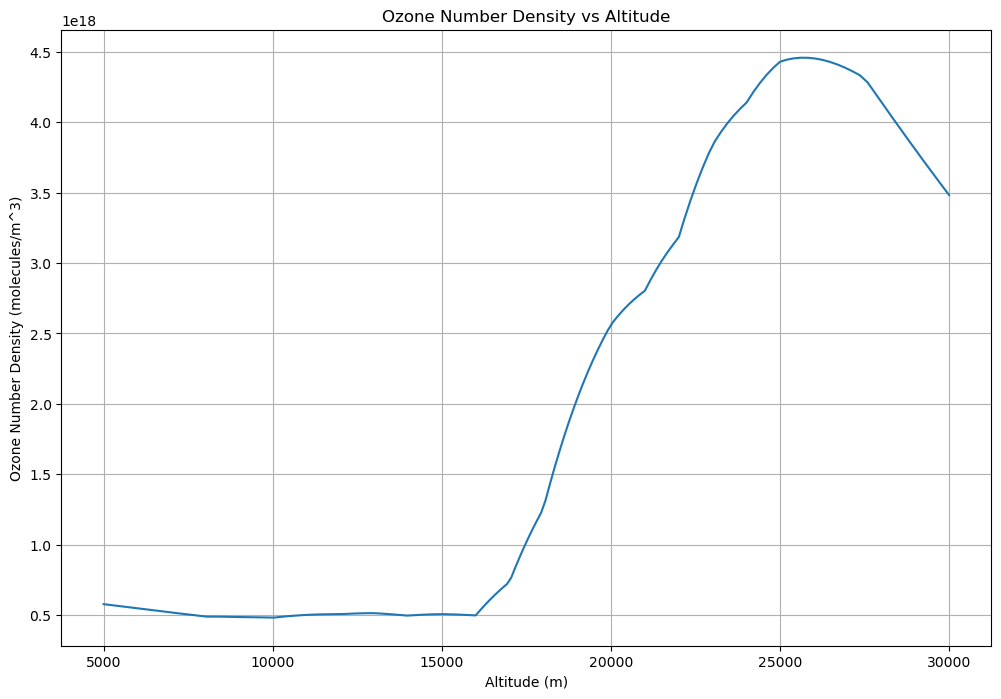

In [238]:
plt.figure(figsize=(12,8))
plt.plot(altitudes, o3n)
plt.xlabel('Altitude (m)')
plt.ylabel('Ozone Number Density (molecules/m^3)')
plt.title('Ozone Number Density vs Altitude')
plt.grid()
plt.show()

In [239]:
#pycraf calc
Tatm_pycraf = Calcul_T_sky_1_el(frq*10**9, altitudes, Temperature, Pressure, P_water, 90)

In [240]:
print(Tatm_pycraf.shape)

(460,)


In [241]:
from pyrtlib.utils import e2mr, mr2rh


gkg = e2mr(Pressure, P_water) #wvmr in g/kg

rh = mr2rh(Pressure, Temperature, gkg)[0] / 100  # RH (not % anymore)

ang = [90.]

rte = TbCloudRTE(altitudes/1000, Pressure, Temperature, rh, frq, ang, o3n)
rte.init_absmdl('R19SD')
O3AbsModel.model = 'R23'
O3AbsModel.set_ll()
rte.satellite = False

df = rte.execute()
df = df.set_index(frq)

tbatm = df.tbatm.values

/opt/miniconda3/envs/lidar/lib/python3.11/site-packages/pyrtlib/tb_spectrum.py:82: UserWarning: Number of levels too low (1000) or minimum pressure value lower than 10 hPa (11.720729447573278). Please considering profile extrapolation. Levels number must be higher than 25 and pressure value lower than 10 hPa
  warnings.warn(f"Number of levels too low ({len(self.p)}) or "


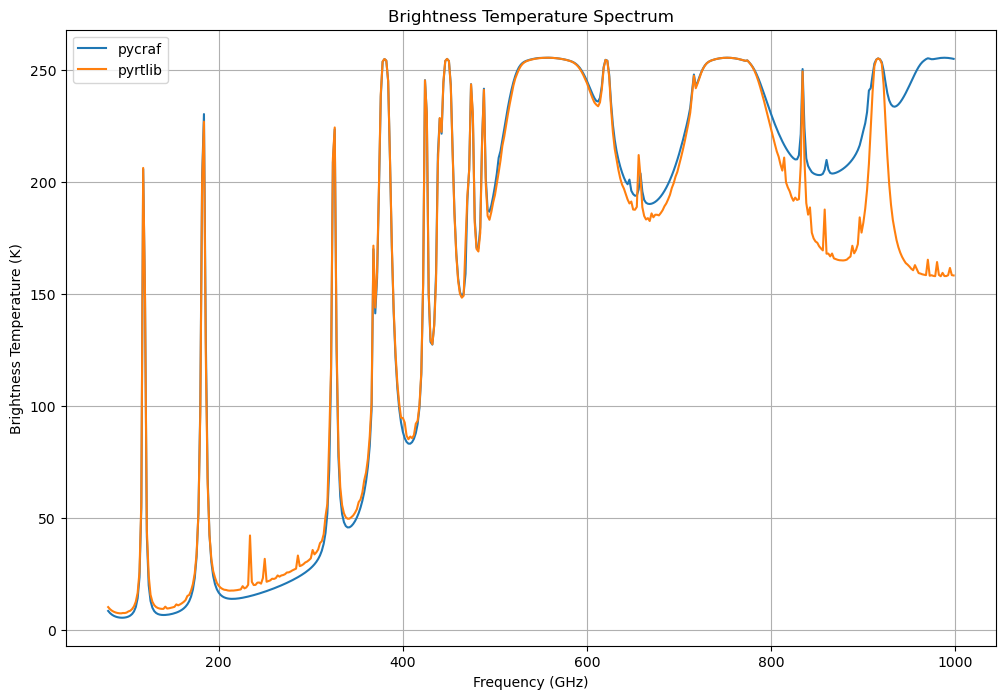

In [242]:
plt.figure(figsize=(12,8))
plt.plot(frq,Tatm_pycraf, label='pycraf')
plt.plot(frq,tbatm, label='pyrtlib')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum')
plt.legend()
plt.grid()
plt.show()

In [233]:
def brightness_to_RJ (Tb, frq):

    h = 6.62607015e-34  # Planck constant in J*s
    k = 1.380649e-23    # Boltzmann constant in J/K

    return h/k*frq/(np.exp(h*frq/(k*Tb))-1)

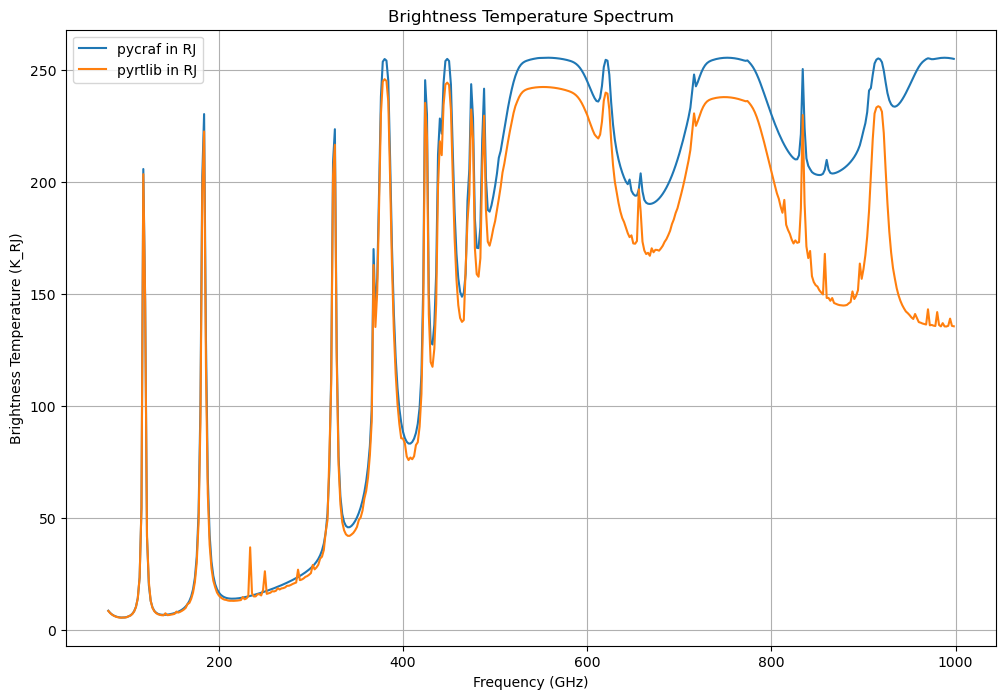

In [243]:
plt.figure(figsize=(12,8))
plt.plot(frq,Tatm_pycraf, label='pycraf in RJ')
plt.plot(frq, brightness_to_RJ(tbatm, frq*1e9), label='pyrtlib in RJ')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K_RJ)')
plt.title('Brightness Temperature Spectrum')
plt.legend()
plt.grid()
plt.show()

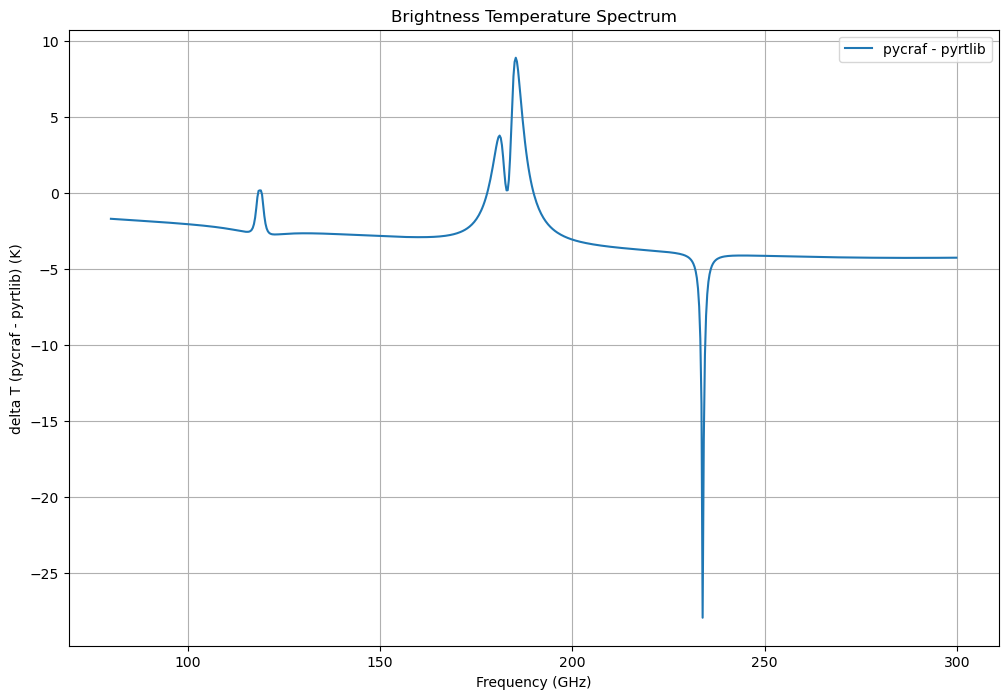

In [81]:
plt.figure(figsize=(12,8))
plt.plot(frq,Tatm_pycraf - tbatm, label='pycraf - pyrtlib')
plt.xlabel('Frequency (GHz)')
plt.ylabel('delta T (pycraf - pyrtlib) (K)')
plt.title('Brightness Temperature Spectrum')
plt.legend()
plt.grid()
plt.show()

In [71]:
def RJ_to_true_T(T_RJ, nu):
    h = 6.626e-34      # Planck constant
    k = 1.381e-23      # Boltzmann constant

    x = h * nu / k
    return x / np.log(1 + x / T_RJ)

In [82]:
Tatm_pycraf_real = RJ_to_true_T(Tatm_pycraf, frq*1e9)

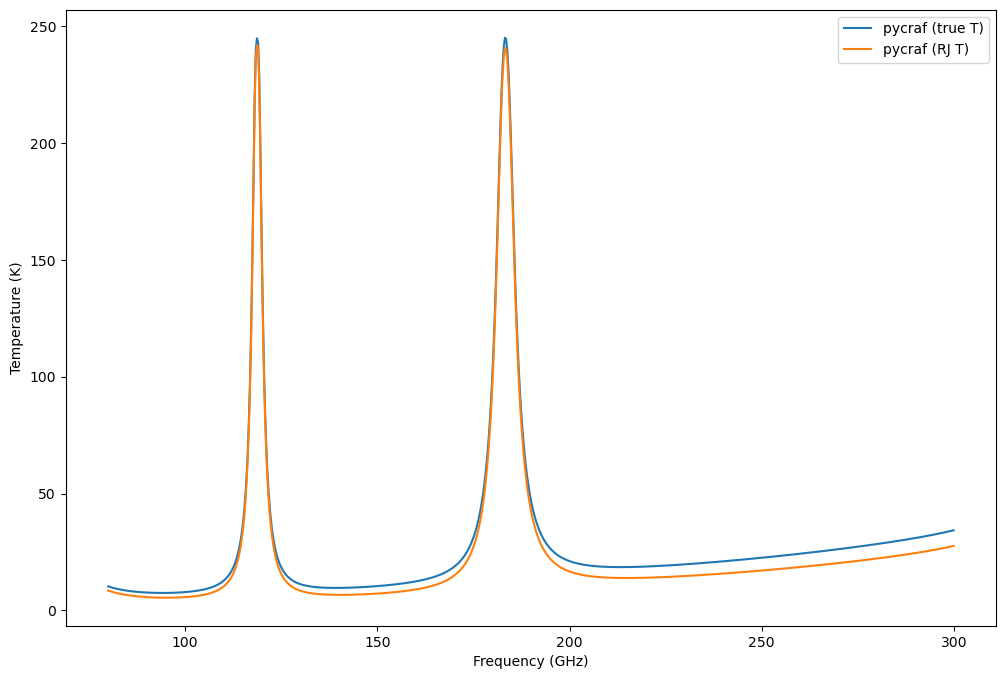

In [83]:
plt.figure(figsize=(12,8))
plt.plot(frq, Tatm_pycraf_real, label='pycraf (true T)')
plt.plot(frq, Tatm_pycraf, label='pycraf (RJ T)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Temperature (K)')
plt.legend()
plt.show()

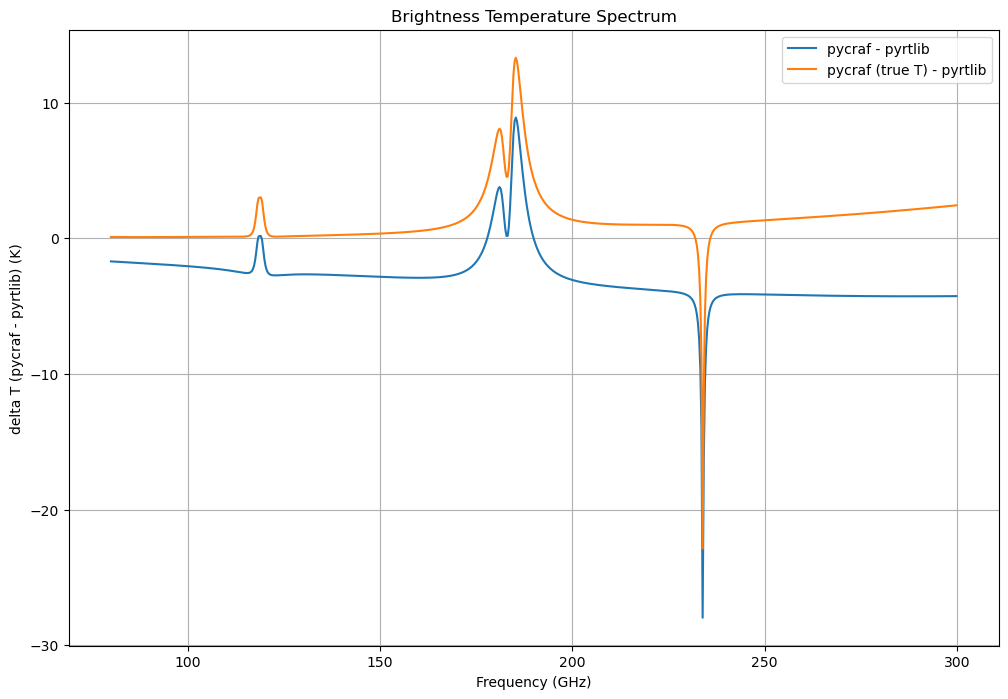

In [84]:
plt.figure(figsize=(12,8))
plt.plot(frq,Tatm_pycraf - tbatm, label='pycraf - pyrtlib')
plt.plot(frq, Tatm_pycraf_real - tbatm, label='pycraf (true T) - pyrtlib')
plt.xlabel('Frequency (GHz)')
plt.ylabel('delta T (pycraf - pyrtlib) (K)')
plt.title('Brightness Temperature Spectrum')
plt.legend()
plt.grid()
plt.show()

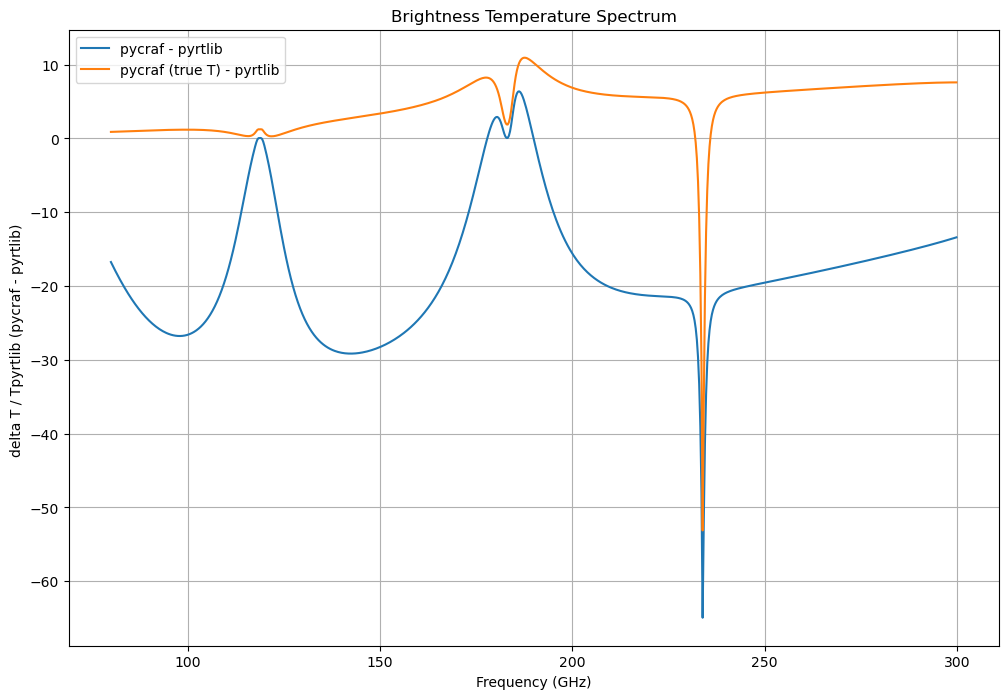

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(frq,(Tatm_pycraf - tbatm)/tbatm*100, label='pycraf - pyrtlib / pyrtlib (%)')
plt.plot(frq, (Tatm_pycraf_real - tbatm)/tbatm*100, label='pycraf (true T) - pyrtlib / pyrtlib (%)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('delta T / Tpyrtlib (pycraf - pyrtlib) ')
plt.title('Brightness Temperature Spectrum')
plt.legend()
plt.grid()
plt.show()

some differences might come to the way of calculating for pyrtlib as it interpolates profiles

In [90]:
#we take the optical depth from pyrtlib 

taudry = df.taudry.values
tauwet = df.tauwet.values
tauliq = df.tauliq.values
tauice = df.tauice.values
tau_tot_pyrtlib = taudry + tauwet + tauliq + tauice

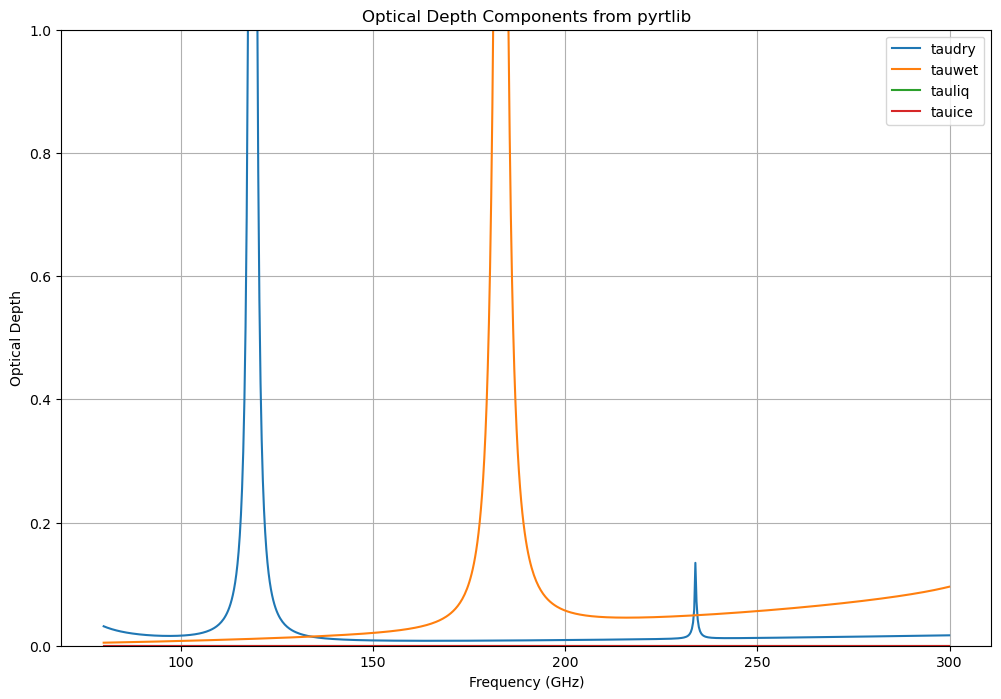

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(frq, taudry, label='taudry')
plt.plot(frq, tauwet, label='tauwet')
plt.plot(frq, tauliq, label='tauliq')
plt.plot(frq, tauice, label='tauice')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Optical Depth')
plt.title('Optical Depth Components from pyrtlib')
plt.legend()
plt.grid()
plt.ylim(0, 1)
plt.show()

In [93]:
from src.cosmo_lidar.atm_tools import atmospheric_transmission
#from pycraf :
tau_tot_pycraf = -np.log(atmospheric_transmission(frq*10**9, altitudes, Temperature, Pressure, P_water, 90))

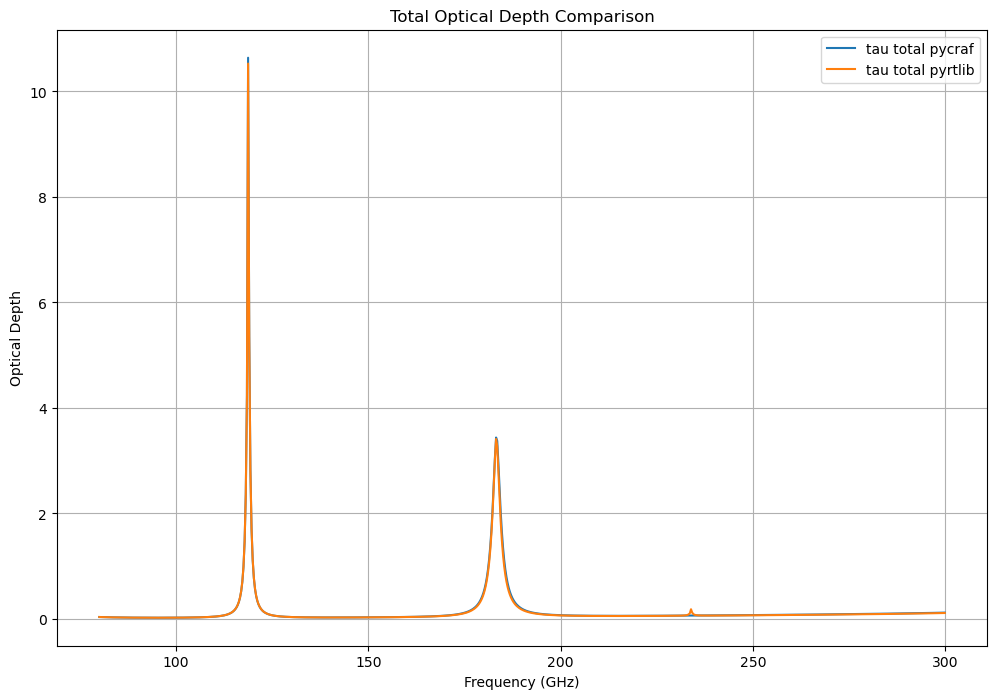

In [94]:
plt.figure(figsize=(12,8))
plt.plot(frq, tau_tot_pycraf, label='tau total pycraf')
plt.plot(frq, tau_tot_pyrtlib, label='tau total pyrtlib')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Optical Depth')
plt.title('Total Optical Depth Comparison')
plt.legend()
plt.grid()
plt.show()

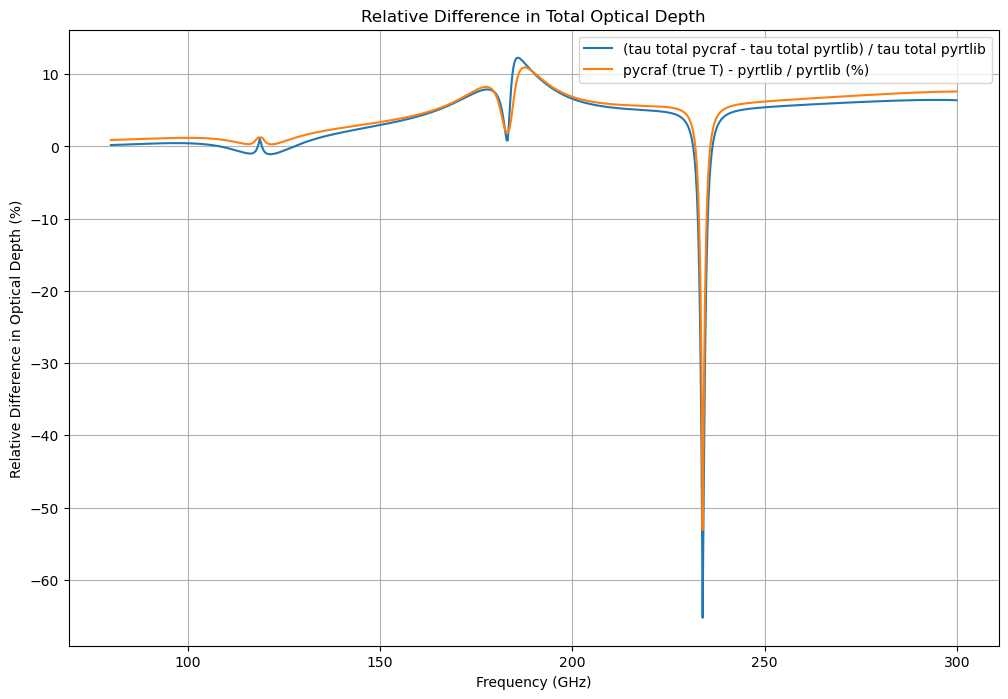

In [135]:
plt.figure(figsize=(12,8))
plt.plot(frq, (tau_tot_pycraf-tau_tot_pyrtlib)/tau_tot_pyrtlib*100, label='(tau total pycraf - tau total pyrtlib) / tau total pyrtlib')
plt.plot(frq, (Tatm_pycraf_real - tbatm)/tbatm*100, label='pycraf (true T) - pyrtlib / pyrtlib (%)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Relative Difference in Optical Depth (%)')
plt.title('Relative Difference in Total Optical Depth')
plt.legend()
plt.grid()
plt.show()

Calculation of alpha from pyrtlib

In [107]:
from pyrtlib.absorption_model import H2OAbsModel, O2AbsModel, O3AbsModel, N2AbsModel

# ==========================================
# 2. Assignation des modèles les plus récents
# ==========================================
# Oxygène
O2AbsModel.model = 'R24'
O2AbsModel.set_ll()

# Vapeur d'eau
H2OAbsModel.model = 'R24' 
H2OAbsModel.set_ll()

# Ozone (Le plus récent est R23)
O3AbsModel.model = 'R23'
O3AbsModel.set_ll()

N2AbsModel.model = 'R24'
N2AbsModel.set_ll()

In [ ]:
from pyrtlib.rt_equation import RTEquation
f1 = 30 #GHz
alpha_wet_pyrtlib, alpha_dry_pyrtlib = RTEquation.clearsky_absorption(Pressure, Temperature, P_water, f1) #in Np/km

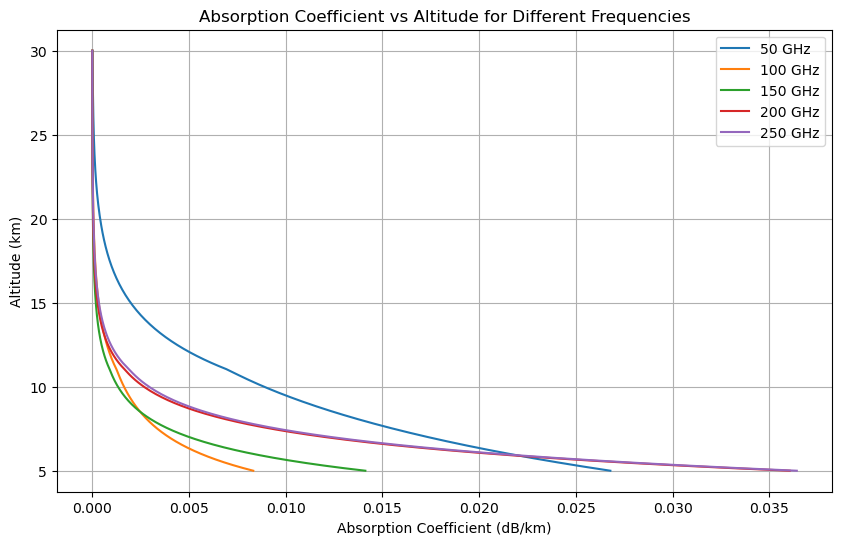

In [ ]:
import matplotlib.pyplot as plt

frequencies = [50, 100, 150, 200, 250]

plt.figure(figsize=(10, 6))

for freq in frequencies:
    alpha_wet, alpha_dry = RTEquation.clearsky_absorption(Pressure, Temperature, P_water, freq)
    alpha_total = alpha_wet + alpha_dry
    plt.plot(alpha_total, altitudes_km.value, label=f'{freq} GHz')

plt.xlabel('Absorption Coefficient (Np/km)')
plt.ylabel('Altitude (km)')
plt.title('Absorption Coefficient vs Altitude for Different Frequencies')
plt.legend()
plt.grid(True)
plt.show()

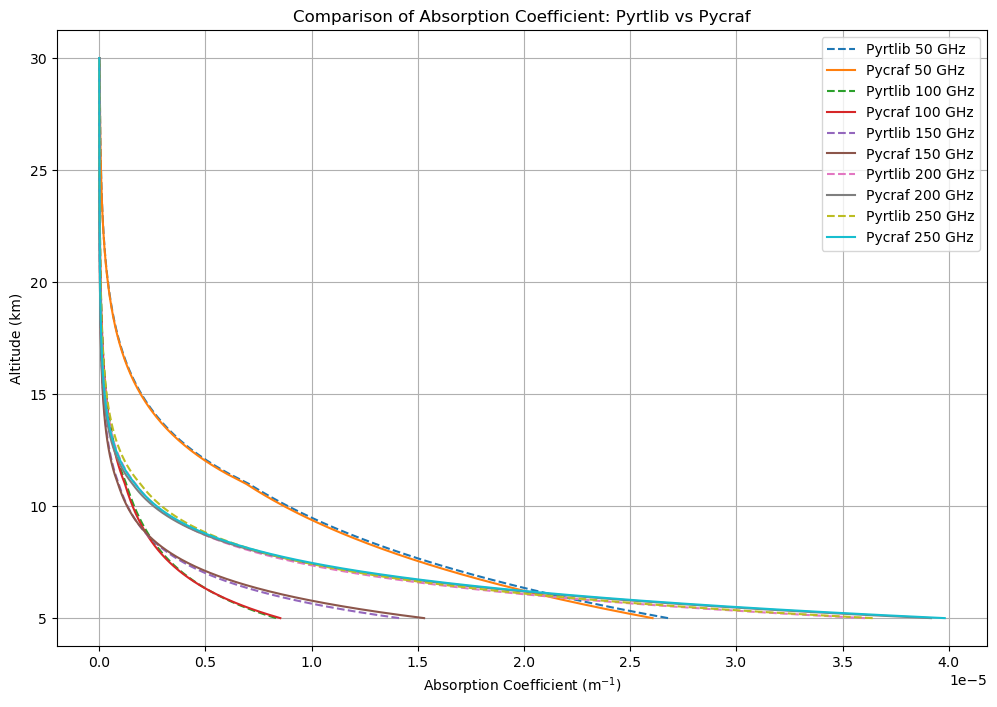

In [115]:
import matplotlib.pyplot as plt
from pyrtlib.rt_equation import RTEquation

frequencies = [50, 100, 150, 200, 250]  # GHz

# Calculate alpha using pycraf (from atm_tools)
alpha_pycraf = alpha_specific_function(altitudes, np.array(frequencies)*1e9, Temperature, Pressure, P_water)  # shape (len(altitudes), len(frequencies)), in m^-1

plt.figure(figsize=(12, 8))

for i, freq in enumerate(frequencies):
    # Pyrtlib alpha in Np/km
    alpha_wet_pyrtlib, alpha_dry_pyrtlib = RTEquation.clearsky_absorption(Pressure, Temperature, P_water, freq)
    alpha_total_pyrtlib = alpha_wet_pyrtlib + alpha_dry_pyrtlib  # Np/km
    
    # Convert pyrtlib to m^-1 for comparison
    alpha_total_pyrtlib_m = alpha_total_pyrtlib / 1000  # m^-1
    
    # Pycraf alpha in m^-1
    alpha_pycraf_freq = alpha_pycraf[:, i]  # m^-1
    
    plt.plot(alpha_total_pyrtlib_m, altitudes_km.value, label=f'Pyrtlib {freq} GHz', linestyle='--')
    plt.plot(alpha_pycraf_freq, altitudes_km.value, label=f'Pycraf {freq} GHz', linestyle='-')

plt.xlabel('Absorption Coefficient (m$^{-1}$)')
plt.ylabel('Altitude (km)')
plt.title('Comparison of Absorption Coefficient: Pyrtlib vs Pycraf')
plt.legend()
plt.grid(True)
plt.show()

In [137]:
import numpy as np
from scipy.integrate import cumulative_trapezoid, trapezoid

alpha_specific = np.zeros((len(altitudes_km), len(frq)))


for j in range(len(frq)):
    alpha_wet, alpha_dry = RTEquation.clearsky_absorption(Pressure, Temperature, P_water, frq[j])  # in Np/km
    alpha_total = alpha_wet + alpha_dry  # Np/km
    alpha_total_m = alpha_total / 1000  # m^-1
    alpha_specific[:,j] = alpha_total_m

tau = optical_depth_emission (altitudes, alpha_specific)
# on définit le terme que l'on va intégrer sur l'altitudes 
C_tot = np.zeros((len(altitudes), len(frq)))
C_tot = alpha_specific * Temperature[:, None] * np.exp(-tau)
T_sky_pyrtlib = trapezoid(C_tot, altitudes, axis=0)




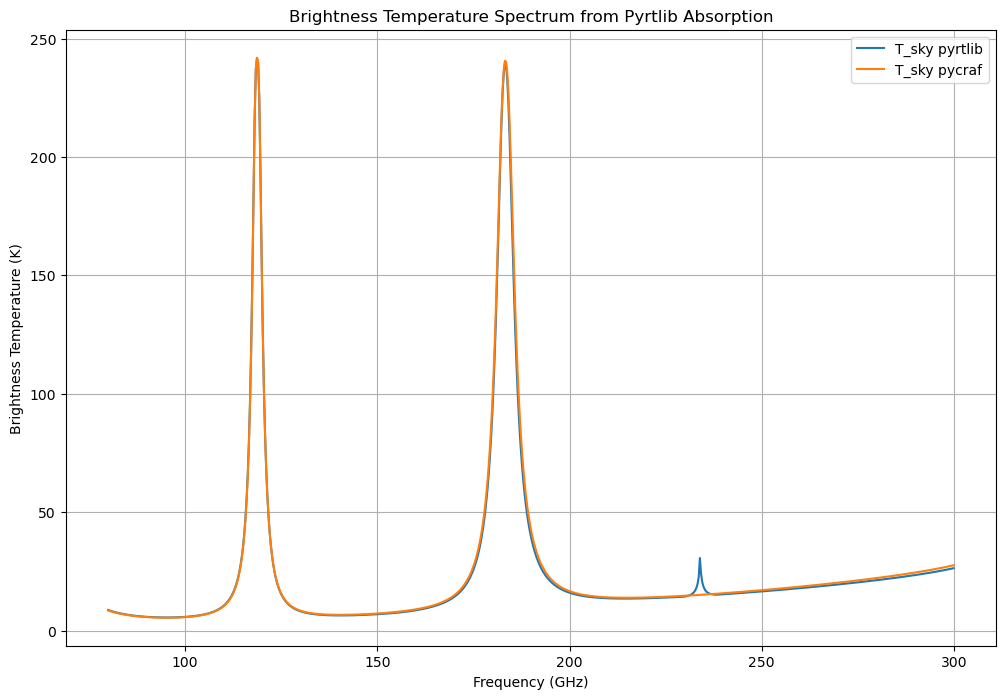

In [139]:
plt.figure(figsize=(12,8))
plt.plot(frq, T_sky_pyrtlib, label='T_sky pyrtlib')
plt.plot(frq, Tatm_pycraf, label='T_sky pycraf')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum from Pyrtlib Absorption')
plt.legend()
plt.grid()
plt.show()

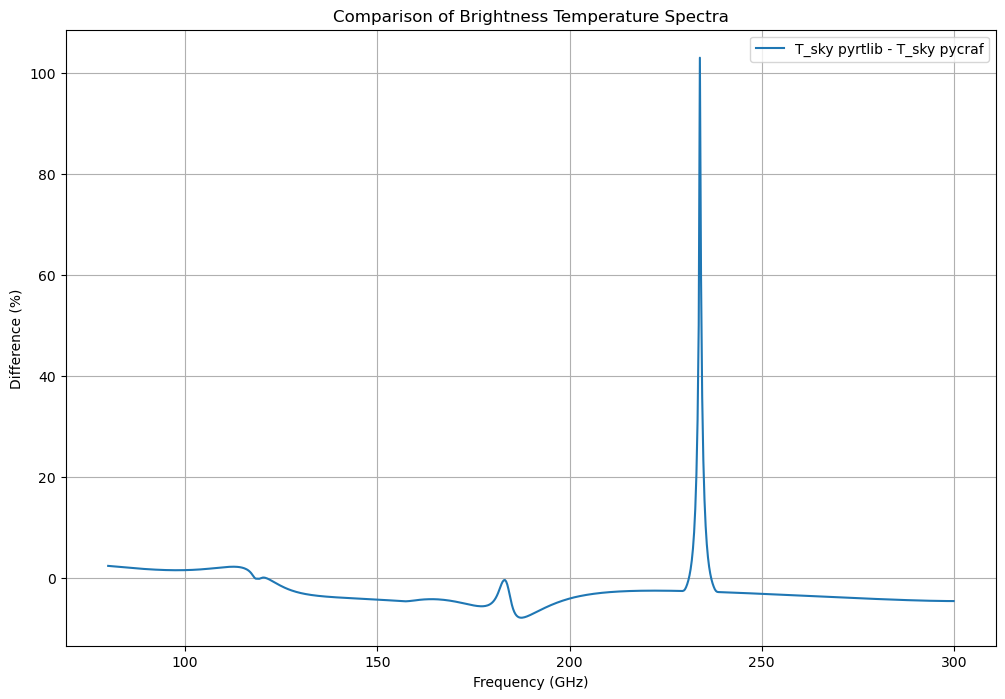

In [140]:
#comparison of the two spectra 

plt.figure(figsize=(12,8))
plt.plot(frq, (T_sky_pyrtlib - Tatm_pycraf) / Tatm_pycraf * 100, label='T_sky pyrtlib - T_sky pycraf')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Difference (%)')
plt.title('Comparison of Brightness Temperature Spectra')
plt.legend()
plt.grid()
plt.show()

In [141]:
#converting the pyrtlib to true temperature using the RJ_to_true_T function defined earlier

T_sky_pyrtlib_true = RJ_to_true_T(T_sky_pyrtlib, frq*1e9)

We calculate using pyrtlib the True Tatm from the latest model

In [244]:
from pyrtlib.utils import e2mr, mr2rh
from pyrtlib.absorption_model import H2OAbsModel, O2AbsModel, O3AbsModel, N2AbsModel


gkg = e2mr(Pressure, P_water) #wvmr in g/kg

rh = mr2rh(Pressure, Temperature, gkg)[0] / 100  # RH (not % anymore)

ang = [90.]


# ==========================================
# 2. Assignation des modèles les plus récents
# ==========================================
# Oxygène
O2AbsModel.model = 'R24'
O2AbsModel.set_ll()

# Vapeur d'eau
H2OAbsModel.model = 'R24' 
H2OAbsModel.set_ll()

# Ozone (Le plus récent est R23)
O3AbsModel.model = 'R23'
O3AbsModel.set_ll()

N2AbsModel.model = 'R24'
N2AbsModel.set_ll()

rte_2 = TbCloudRTE(altitudes/1000, Pressure, Temperature, rh, frq, ang)
rte_2.satellite = False

df_2, rt_vars = rte_2.execute(False)
#df_2 = df_2.set_index(frq)

tbatm_2 = df_2.tbatm.values

/opt/miniconda3/envs/lidar/lib/python3.11/site-packages/pyrtlib/tb_spectrum.py:82: UserWarning: Number of levels too low (1000) or minimum pressure value lower than 10 hPa (11.720729447573278). Please considering profile extrapolation. Levels number must be higher than 25 and pressure value lower than 10 hPa
  warnings.warn(f"Number of levels too low ({len(self.p)}) or "


In [155]:
print(df_2)

       tbtotal      tbatm         tmr  tmrcld    tauwet    taudry  tauliq  \
0    11.434743  10.222316  236.684472     0.0  0.004626  0.031909     0.0   
1    11.270290  10.060402  236.714771     0.0  0.004661  0.031136     0.0   
2    11.113863   9.906551  236.745385     0.0  0.004696  0.030400     0.0   
3    10.965012   9.760310  236.776283     0.0  0.004731  0.029697     0.0   
4    10.823319   9.621259  236.807438     0.0  0.004766  0.029026     0.0   
..         ...        ...         ...     ...       ...       ...     ...   
729  30.720478  30.651629  243.803725     0.0  0.089995  0.017104     0.0   
730  30.825199  30.756684  243.809178     0.0  0.090423  0.017133     0.0   
731  30.931488  30.863304  243.814733     0.0  0.090858  0.017163     0.0   
732  31.039408  30.971556  243.820394     0.0  0.091301  0.017193     0.0   
733  31.149028  31.081505  243.826165     0.0  0.091752  0.017223     0.0   

     tauice  angle  
0       0.0   90.0  
1       0.0   90.0  
2       0.0 

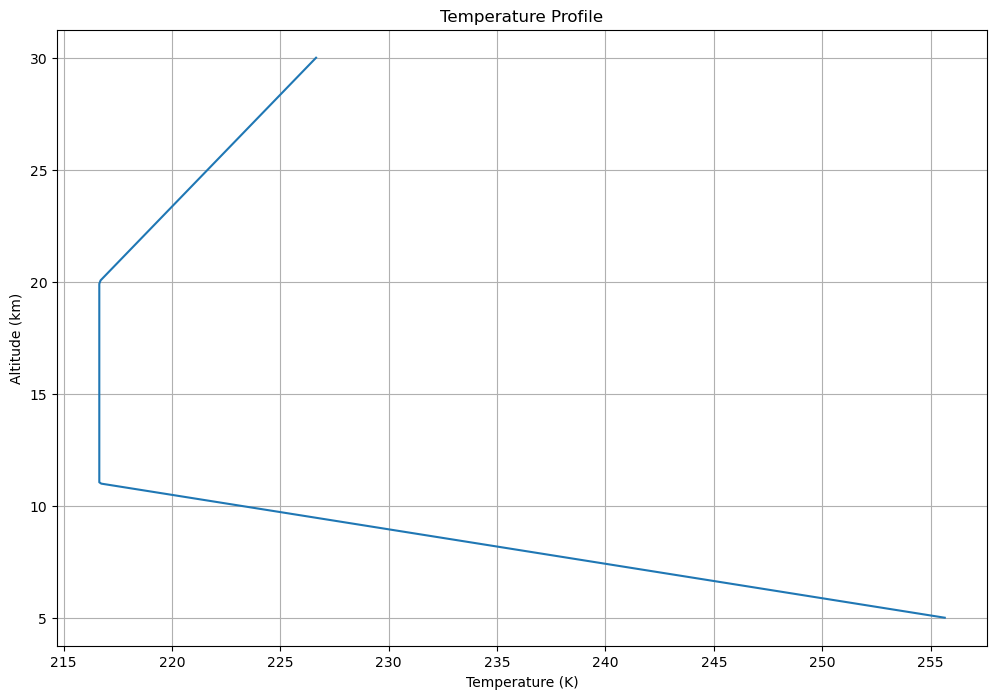

In [249]:
#ploting temperature as a function of altitude 

plt.figure(figsize=(12,8))
plt.plot(Temperature, altitudes_km.value)
plt.xlabel('Temperature (K)')
plt.ylabel('Altitude (km)')
plt.title('Temperature Profile')
plt.grid()
plt.show()

In [257]:
from src.cosmo_lidar.atm_tools import Calcul_T_sky_1_el_bb

In [258]:
T_atm_pycraf_bb = Calcul_T_sky_1_el_bb(frq*1e9, altitudes, Temperature, Pressure, P_water, 90) # in K_RJ using the blackbody function

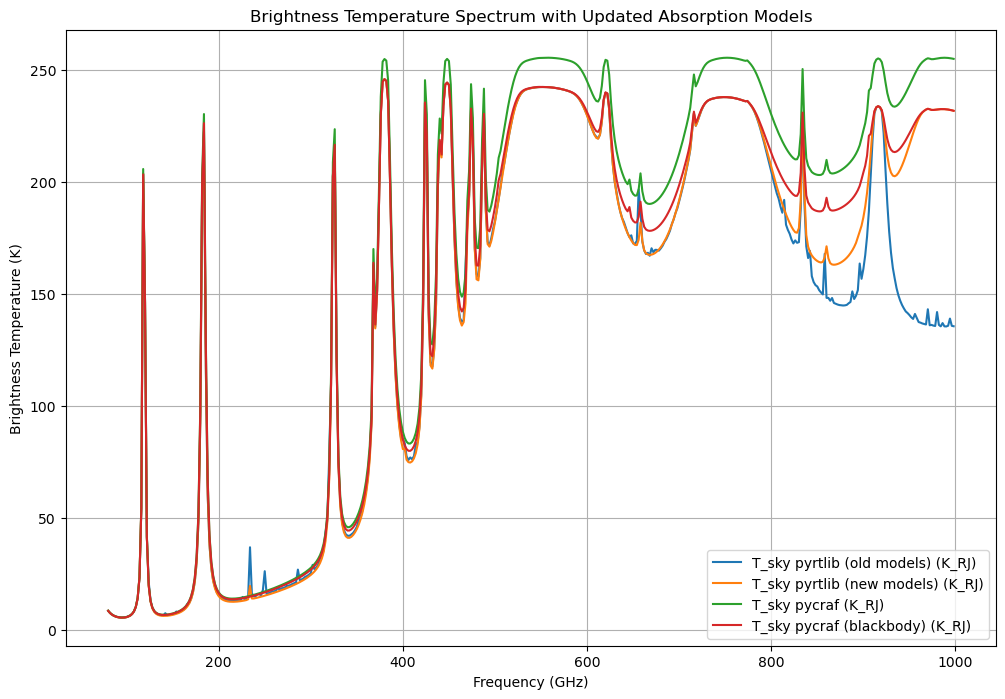

In [259]:
plt.figure(figsize=(12,8))
plt.plot(frq, brightness_to_RJ(tbatm,frq*1e9), label='T_sky pyrtlib (old models) (K_RJ)')
plt.plot(frq, brightness_to_RJ(tbatm_2,frq*1e9), label='T_sky pyrtlib (new models) (K_RJ)')
plt.plot(frq, Tatm_pycraf, label='T_sky pycraf (K_RJ)')
plt.plot(frq, T_atm_pycraf_bb, label='T_sky pycraf (blackbody) (K_RJ)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum with Updated Absorption Models')
plt.legend()
plt.grid()
plt.show()

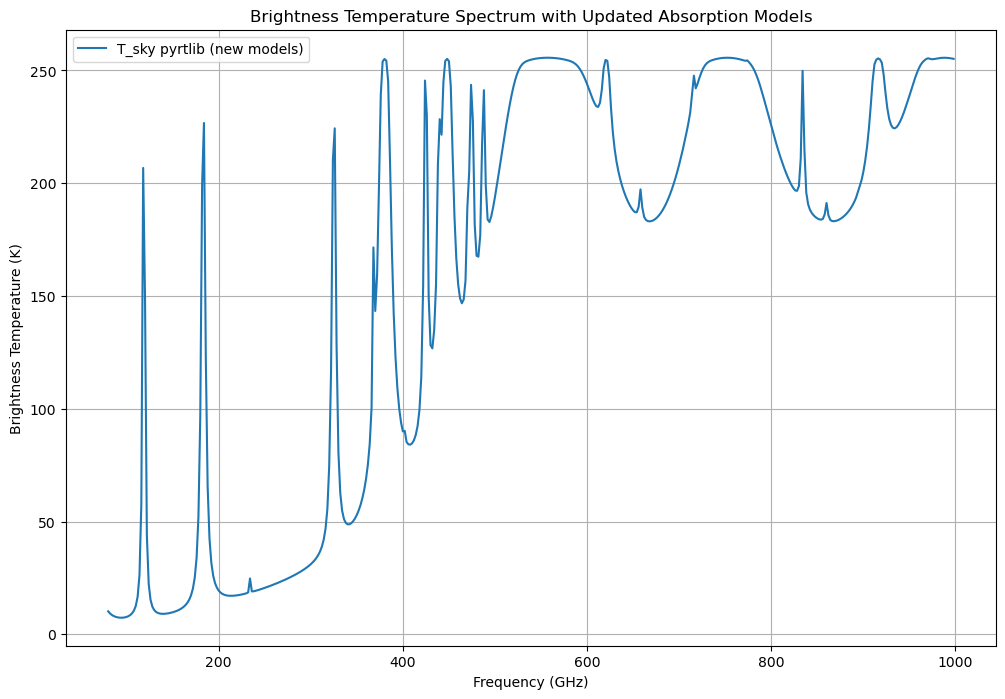

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(frq, tbatm_2, label='T_sky pyrtlib (new models)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum with Updated Absorption Models')
plt.legend()
plt.grid()
plt.show()

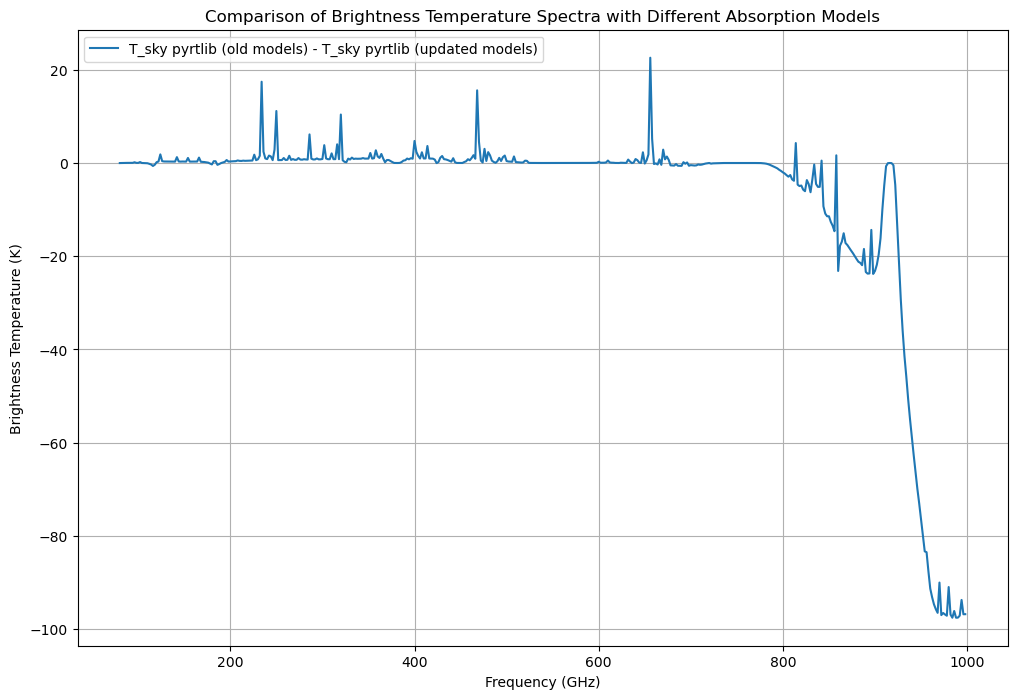

In [246]:
#comparison between the first pyrtlib spectrum and the second one with the updated absorption models

plt.figure(figsize=(12,8))
plt.plot(frq, (tbatm-tbatm_2), label='T_sky pyrtlib (old models) - T_sky pyrtlib (updated models)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Comparison of Brightness Temperature Spectra with Different Absorption Models')
plt.legend()
plt.grid()
plt.show()


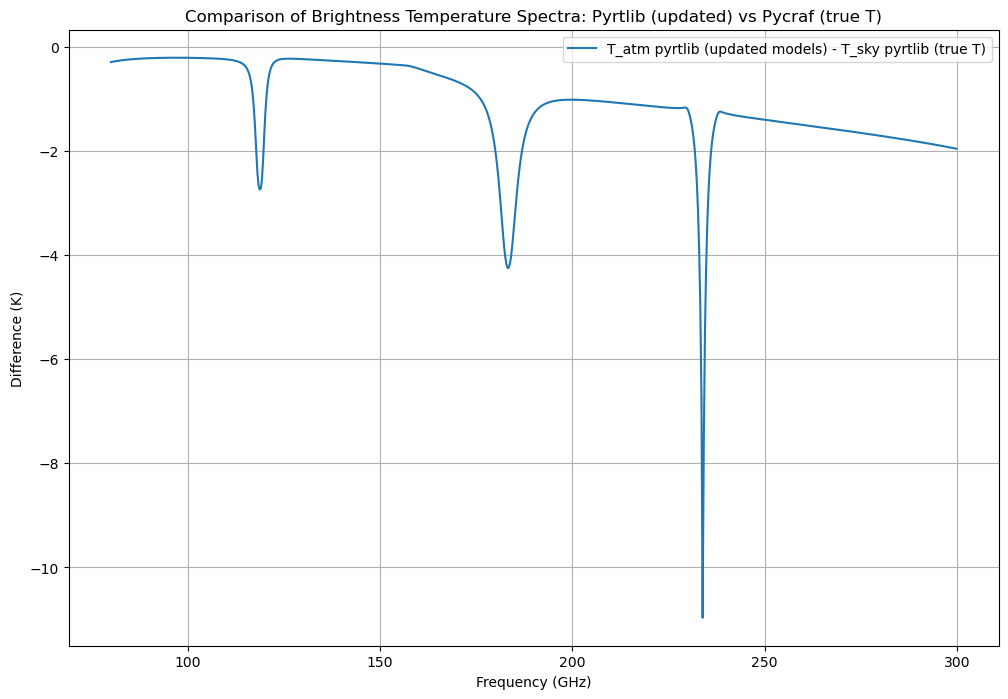

In [148]:
#comparison of the spetra with the updated models of pyrtlib to the sky temperature sprectrum with  pyrtlib in true K

plt.figure(figsize=(12,8))
plt.plot(frq, (tbatm_2 - T_sky_pyrtlib_true), label='T_atm pyrtlib (updated models) - T_sky pyrtlib (true T)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Difference (K)')
plt.title('Comparison of Brightness Temperature Spectra: Pyrtlib (updated) vs Pycraf (true T)')
plt.legend()
plt.grid()
plt.show()

Let's compare now the full tau between the tbcloudrte and just getting alpha from rtequation then integrating

In [156]:
#for the tbcloudrte

tauwet_2 = df_2.tauwet.values
taudry_2 = df_2.taudry.values
tau_tot_pyrtlib_2 = tauwet_2 + taudry_2

In [161]:
print(tau.shape)
print(tau_tot_pyrtlib_2.shape)

(1000, 734)
(734,)


In [160]:
#from rtequation 
tau_tot_pyrtlib_2_rt = tau [-1, :]
print(tau_tot_pyrtlib_2_rt.shape)

(734,)


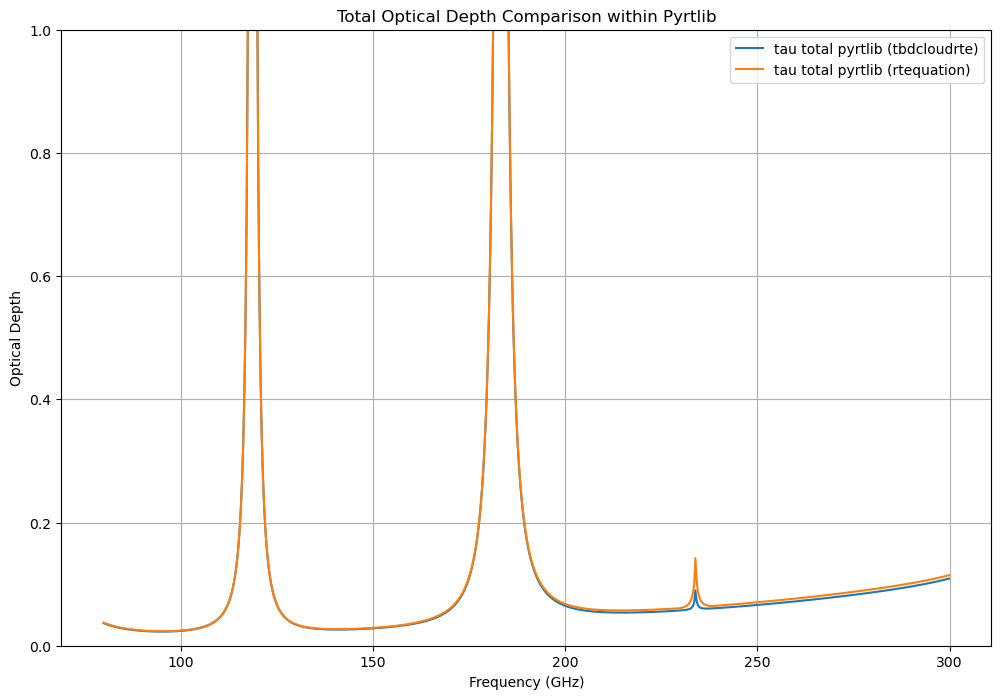

In [163]:
plt.figure(figsize=(12,8))
plt.plot(frq, tau_tot_pyrtlib_2, label='tau total pyrtlib (tbdcloudrte)')
plt.plot(frq, tau_tot_pyrtlib_2_rt, label='tau total pyrtlib (rtequation)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Optical Depth')
plt.title('Total Optical Depth Comparison within Pyrtlib')
plt.legend()
plt.grid()
plt.ylim(0, 1)
plt.show()

Calculation with the latest model

In [268]:

from pyrtlib.utils import e2mr, mr2rh
from pyrtlib.absorption_model import H2OAbsModel, O2AbsModel, O3AbsModel, N2AbsModel


gkg = e2mr(Pressure, P_water) #wvmr in g/kg

rh = mr2rh(Pressure, Temperature, gkg)[0] / 100  # RH (not % anymore)

ang = [90.]


# ==========================================
# 2. Assignation des modèles les plus récents
# ==========================================
# Oxygène
O2AbsModel.model = 'R24'
O2AbsModel.set_ll()

# Vapeur d'eau
H2OAbsModel.model = 'R24' 
H2OAbsModel.set_ll()

# Ozone (Le plus récent est R23)
O3AbsModel.model = 'R23'
O3AbsModel.set_ll()

N2AbsModel.model = 'R24'
N2AbsModel.set_ll()

rte_2 = TbCloudRTE(altitudes/1000, Pressure, Temperature, rh, frq, ang)
rte_2.satellite = False

df_2, rt_vars = rte_2.execute(False)
#df_2 = df_2.set_index(frq)

tbatm_2 = df_2.tbatm.values

/opt/miniconda3/envs/lidar/lib/python3.11/site-packages/pyrtlib/tb_spectrum.py:82: UserWarning: Number of levels too low (1000) or minimum pressure value lower than 10 hPa (11.720729447573278). Please considering profile extrapolation. Levels number must be higher than 25 and pressure value lower than 10 hPa
  warnings.warn(f"Number of levels too low ({len(self.p)}) or "


In [269]:
import numpy as np
from scipy.integrate import cumulative_trapezoid, trapezoid
from src.cosmo_lidar.atm_tools import planck_source

frequency = frq * 1e9  # Convert GHz to Hz

alpha_specific = np.zeros((len(altitudes_km), len(frq)))


for j in range(len(frq)):
    alpha_wet, alpha_dry = RTEquation.clearsky_absorption(Pressure, Temperature, P_water, frq[j])  # in Np/km
    alpha_total = alpha_wet + alpha_dry  # Np/km
    alpha_total_m = alpha_total / 1000  # m^-1
    alpha_specific[:,j] = alpha_total_m





In [270]:
from scipy import constants
c=constants.c
kb=constants.k


dz = np.diff(altitudes) # Shape: (len(altitudes)-1,)

# Calculate Midpoint Properties for each slab
# We average the values between index i and i+1
T_mid = (Temperature[:-1] + Temperature[1:]) / 2.0
alpha_mid = (alpha_specific[:-1, :] + alpha_specific[1:, :]) / 2.0

# d_tau is the optical thickness of each individual slab
d_tau = alpha_mid * dz[:, None]

# 4. Calculate Tau Below (Cumulative attenuation from ground to layer i)
# tau_below for the 1st layer is 0. 
# For subsequent layers, it's the sum of d_tau of all layers below it.
tau_below = np.cumsum(d_tau, axis=0)
tau_below = np.insert(tau_below[:-1, :], 0, 0, axis=0) # Shift so first layer has 0 attenuation

# 5 Calculate the Planck function at the mid-layer temperature for each frequency
B_nu_mid = planck_source(frequency[None,:], T_mid[:, None])  # shape (N_alt-1, N_freq)
# 5. Apply the Summation
# Layer Emission = T * (1 - exp(-d_tau * m))
# Transmission to ground = exp(-tau_below * m)
I_layers = B_nu_mid * (1 - np.exp(-d_tau)) * np.exp(-tau_below)

I_nu = np.sum(I_layers, axis=0) # radiance in W/m^2/Hz/sr

T_sky_newmodel_alphaPyrtlib = (c**2 / (2 * kb * frequency**2)) * I_nu  # Convert radiance to brightness temperature in K_RJ

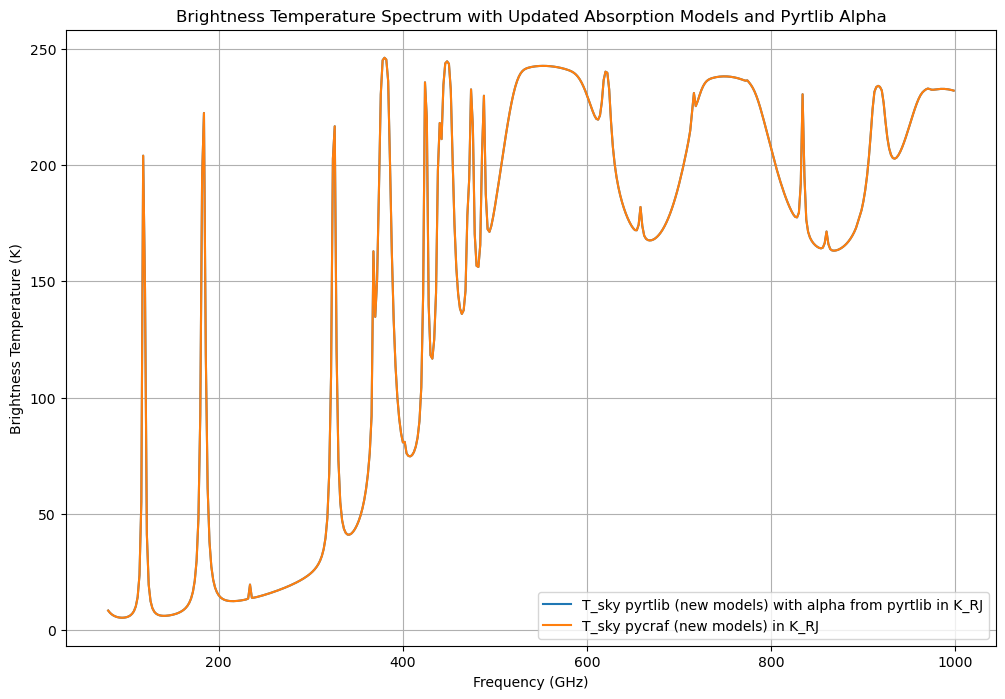

In [273]:
plt.figure(figsize=(12,8))
plt.plot(frq, T_sky_newmodel_alphaPyrtlib, label='T_sky pyrtlib (new models) with alpha from pyrtlib in K_RJ')
plt.plot(frq, brightness_to_RJ(tbatm_2, frq*1e9), label='T_sky pycraf (new models) in K_RJ')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum with Updated Absorption Models and Pyrtlib Alpha')
plt.legend()
plt.grid()
plt.show()

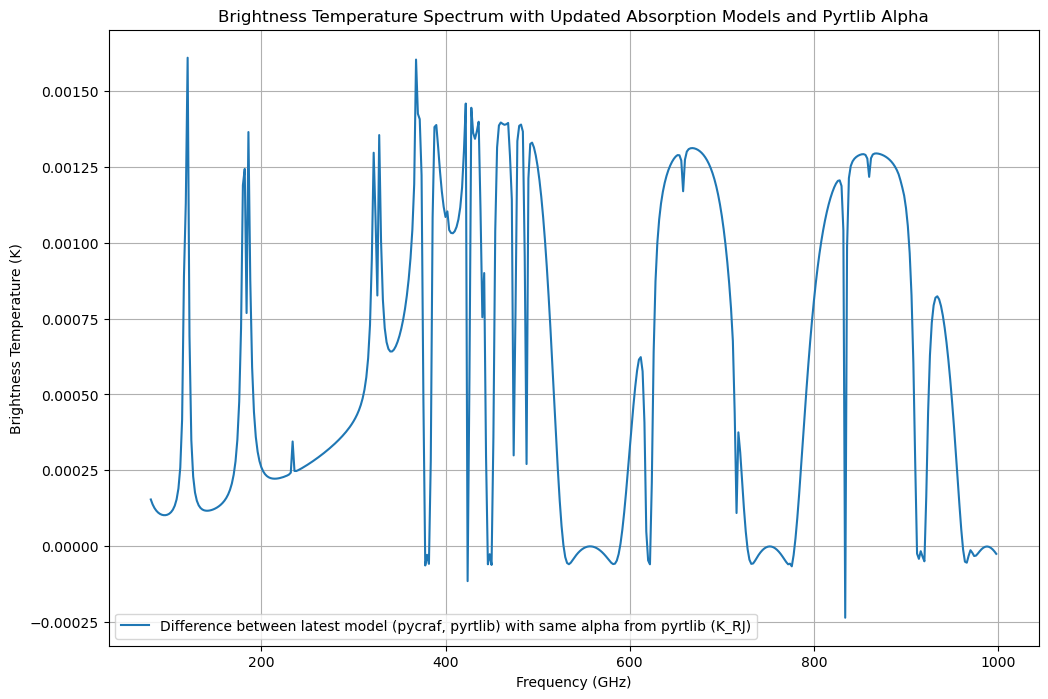

In [274]:
plt.figure(figsize=(12,8))
plt.plot(frq, T_sky_newmodel_alphaPyrtlib - brightness_to_RJ(tbatm_2, frq*1e9), label='Difference between latest model (pycraf, pyrtlib) with same alpha from pyrtlib (K_RJ)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum with Updated Absorption Models and Pyrtlib Alpha')
plt.legend()
plt.grid()
plt.show()